✅ Dependencies imported

🏦 IDX STOCK SCANNER - Medallion Style (Swing + FGV)
✅ Berhasil konek ke Google Sheets

📊 Google Sheets URL: https://docs.google.com/spreadsheets/d/17vhCnEIA_p_7obIODa7hPx4OIs-6slK9dsckpKK9MoA

Pilih Mode:
1. Inisialisasi Data Warehouse
2. Phase 1 - Trading Scanner (Jalankan Semua Engine)
3. System Quality Dashboard (Backtest End-to-End)
4. Exit

Pilihan (1/2/3/4): 3

📊 SYSTEM QUALITY DASHBOARD (End-to-End Backtest)
Periode: 2021-04-03 - 2026-04-02 | Saham: 637
Interval scanning: setiap 15 hari | Holding: 10 hari | Modal simulasi: Rp 5,000,000

🔄 Menjalankan backtest (ini akan memakan waktu beberapa menit)...

📡 FETCHING GLOBAL INDICES

📊 IHSG: Indeks Harga Saham Gabungan (^JKSE)
   ✅ Harga: 7,184.44

📊 DOWJONES: Dow Jones Industrial Average (^DJI)
   ✅ Harga: 46,565.74

📊 USDIDR: USD/IDR (IDR=X)
   ✅ Harga: Rp 16,936

📊 OIL: Crude Oil WTI (CL=F)
   ✅ Harga: US$ 100.12

📊 GOLD: Gold Futures (GC=F)
   ✅ Harga: US$ 4783.20

📊 NIKKEI: Nikkei 225 (^N225)
   ✅ Harga:

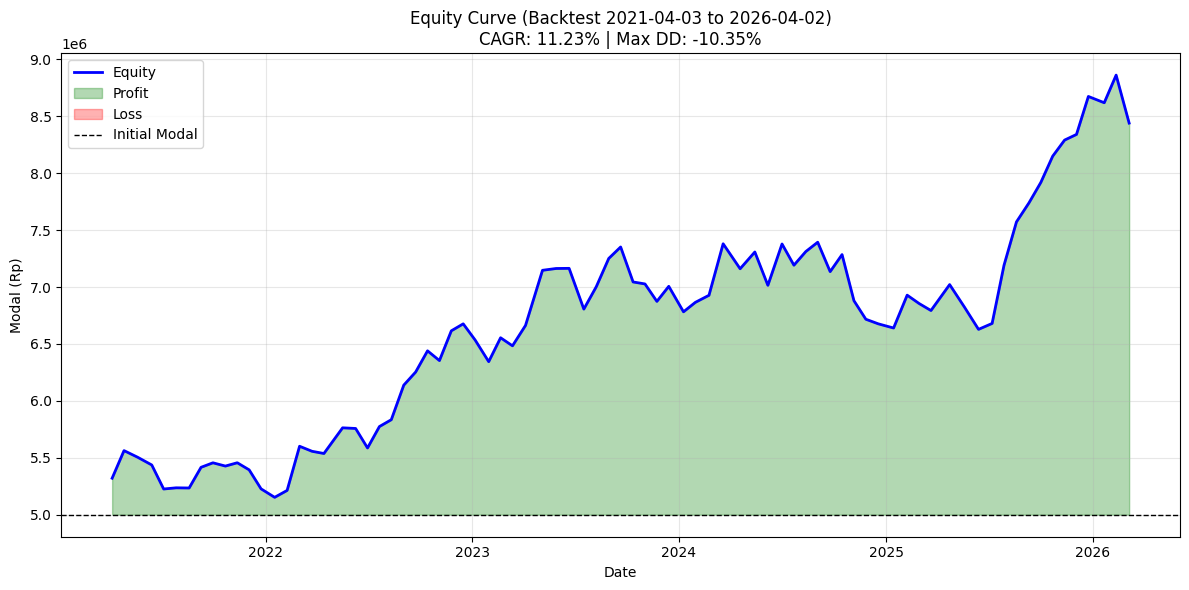

In [ ]:
# -*- coding: utf-8 -*-
"""IDX Stock Scanner - Medallion Style (Swing + FGV)"""

# =============================================================================
# 0. INSTALL LIBRARY TAMBAHAN
# =============================================================================
!pip install -q ta
!pip install -q mplfinance

# =============================================================================
# 1. DEPENDENCIES & IMPORTS
# =============================================================================
import mplfinance as mpf
import matplotlib.pyplot as plt
from google.colab import auth
from google.auth import default
import gspread
import yfinance as yf
import pandas as pd
import numpy as np
import warnings
from datetime import datetime, timedelta
import time
import pickle
import os
import json
from tabulate import tabulate
from collections import defaultdict
import logging
import random
from typing import Optional, Dict, List, Tuple, Union, Any
import hashlib
import matplotlib.pyplot as plt
import math
import ta
import glob

# Matikan logging yang tidak perlu
logging.getLogger('yfinance').setLevel(logging.CRITICAL)
warnings.filterwarnings('ignore')

# Setup logging untuk error handling
logging.basicConfig(
    filename='scanner_errors.log',
    level=logging.ERROR,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

print("✅ Dependencies imported")

# =============================================================================
# 2. STOCK UNIVERSE (FULL) - TIDAK BERUBAH
# =============================================================================
STOCKBIT_UNIVERSE = [
    "AALI", "ABBA", "ABDA", "ABMM", "ACES", "ADES", "ADHI", "ADMF", "ADMG", "ADRO",
    "AGAR", "AGII", "AGRO", "AHAP", "AIMS", "AISA", "AKRA", "AKSI", "ALDO", "ALKA",
    "ALMI", "AMAG", "AMFG", "AMMN", "AMRT", "ANDI", "ANJT", "ANTM", "APEX", "APIC",
    "APLN", "ARCI", "ARGO", "ARII", "ARNA", "ARTA", "ARTO", "ASBI", "ASDM", "ASGR",
    "ASHA", "ASII", "ASLI", "ASMI", "ASPI", "ASRI", "ASRM", "ASSA", "ATLA", "AUTO",
    "AVIA", "AWAN", "AYLS", "BABP", "BACA", "BALI", "BANK", "BAPA", "BAPI", "BATA",
    "BAYU", "BBCA", "BBHI", "BBKP", "BBLD", "BBNI", "BBRI", "BBRM", "BBSS", "BBTN",
    "BBYB", "BCAP", "BCIC", "BDMN", "BEEF", "BEKS", "BELL", "BEST", "BFIN", "BGTG",
    "BHAT", "BIMA", "BINA", "BIPP", "BIPI", "BIRD", "BISI", "BJBR", "BJTM", "BKSL",
    "BLTA", "BLUE", "BMAS", "BMBL", "BMRI", "BMSR", "BMTR", "BNBA", "BNBR", "BNGA",
    "BNII", "BNLI", "BOBA", "BOLT", "BOSS", "BPFI", "BPII", "BPTR", "BRAM", "BREN",
    "BRIS", "BRMS", "BRNA", "BRPT", "BSDE", "BSIM", "BSSR", "BTEL", "BTON", "BTPN",
    "BTPS", "BUDI", "BULL", "BUMI", "BUVA", "BWPT", "BYAN", "CAMP", "CANI", "CARS",
    "CASA", "CASS", "CBDK", "CBMF", "CCSI", "CDAX", "CEKA", "CENT", "CFIN", "CITA",
    "CITY", "CKRA", "CLEO", "CLPI", "CMNP", "CMPP", "CMRY", "CNKO", "CNTX", "COAL",
    "COCO", "COWL", "CPIN", "CPRO", "CSAP", "CSIS", "CTBN", "CTRA", "CTTH", "CUAN",
    "DAAZ", "DART", "DASA", "DAYA", "DCII", "DEGA", "DEWA", "DFAM", "DGIK", "DIGI",
    "DILD", "DIVA", "DIVN", "DKFT", "DLTA", "DMAS", "DMND", "DNAR", "DNET", "DNLS",
    "DOID", "DOOH", "DPNS", "DPUM", "DSFI", "DSNG", "DSSA", "DUCK", "DUTI", "DVLA",
    "DYAN", "EASI", "EASY", "EBMT", "ECII", "EDGE", "EKAD", "ELBA", "ELSA", "ELTY",
    "EMBR", "EMDE", "EMTK", "ENRG", "ENVY", "ENZO", "EPAC", "EPMT", "ERAA", "ERTX",
    "ESSA", "ESTA", "ESTI", "ETWA", "EXCL", "FAST", "FASW", "FILM", "FISH", "FITT",
    "FKSF", "FLMC", "FMII", "FORE", "FORU", "FORZ", "FPNI", "FREN", "FUJI", "FUTR",
    "GAMA", "GDST", "GDYR", "GEMS", "GGRM", "GGRP", "GHON", "GIDS", "GJTL", "GLVA",
    "GMFI", "GMTD", "GOLD", "GOOD", "GOTO", "GPRA", "GRPH", "GSMF", "GTBO", "GTRA",
    "GTSI", "GULA", "GZCO", "HADE", "HDFA", "HDIT", "HEAL", "HERO", "HITS", "HKMU",
    "HMSP", "HOKI", "HOMI", "HOPE", "HOTL", "HRME", "HRTA", "HRUM", "HSBK", "HSMP",
    "HUMI", "IBFN", "IBOS", "IBST", "ICBP", "ICON", "IDPR", "IFII", "IFSH", "IGAR",
    "IIKP", "IKAI", "IKAN", "IMAS", "IMJS", "IMPC", "INAF", "INAI", "INCF", "INCI",
    "INCO", "INDF", "INDS", "INDX", "INDY", "INET", "INKP", "INPC", "INPP", "INPS",
    "INRU", "INTA", "INTD", "INTP", "IPCC", "IPCM", "IPOL", "IRRA", "ISAT", "ISEA",
    "ISSP", "ITIC", "ITMG", "JAST", "JAWA", "JAYA", "JECC", "JEMB", "JFAS", "JGLE",
    "JHON", "JIHD", "JKON", "JKSW", "JMAS", "JPFA", "JPII", "JPUR", "JRPT", "JSKY",
    "JSMR", "JSPT", "JTNB", "KAEF", "KAQI", "KARW", "KBLI", "KBLM", "KBRT", "KBRI",
    "KDSI", "KDTN", "KEEN", "KETR", "KICI", "KIJA", "KINO", "KIOS", "KJEN", "KKGI",
    "KLBF", "KMTR", "KOBX", "KOIN", "KOLI", "KONI", "KOTA", "KPAL", "KPIG", "KRAS",
    "KREN", "KRYA", "KSEL", "KUAS", "KUIC", "KUVO", "LAND", "LAPD", "LATA", "LBAK",
    "LCGP", "LCKM", "LEAD", "LIFE", "LINK", "LION", "LISA", "LMAS", "LMPI", "LMSH",
    "LPCK", "LPGI", "LPIN", "LPKR", "LPLI", "LPPF", "LPPS", "LSIP", "LSPI", "LTLS",
    "LUCY", "MABA", "MABH", "MAGP", "MAIN", "MAMI", "MAPA", "MAPB", "MAPI", "MARA",
    "MASA", "MAYA", "MBAP", "MBCA", "MBMA", "MBSS", "MBTO", "MCAS", "MCPI", "MCOR",
    "MDIA", "MDKA", "MDKI", "MEDC", "MEDS", "MEGA", "MERK", "META", "MFIN", "MFMI",
    "MGLV", "MGNA", "MGRO", "MIDI", "MIKA", "MINA", "MIRA", "MITI", "MITT", "MKNT",
    "MKPI", "MLBI", "MLIA", "MLPL", "MLPT", "MLSL", "MMIX", "MMLP", "MNCN", "MOLI",
    "MPOW", "MPPA", "MPRO", "MPTJ", "MRAT", "MSIE", "MSIN", "MSKY", "MTDL", "MTFN",
    "MTLA", "MTPS", "MTSM", "MUDA", "MUTU", "MYOH", "MYOR", "MYRX", "MYSX", "NAGA",
    "NASI", "NATO", "NAYZ", "NCKL", "NELY", "NETV", "NFCX", "NICL", "NIKL", "NISP",
    "NITY", "NIYM", "NOBU", "NPGF", "NRCA", "NSSS", "NTBK", "NUSA", "NUSI", "OASA",
    "OCTN", "OKAS", "OMED", "ONIX", "OPMS", "ORNA", "OTBK", "PADA", "PADI", "PAMG",
    "PANR", "PANS", "PANU", "PAPA", "PASA", "PASS", "PBRX", "PBID", "PBSA", "PCAR",
    "PDES", "PDGD", "PDIN", "PEGE", "PGAS", "PGLI", "PGUN", "PICO", "PIDRA", "PJAA",
    "PKPK", "PLAN", "PLAS", "PLIN", "PMJS", "PMMP", "PNBN", "PNBS", "PNIN", "PNLF",
    "PNSE", "POLI", "POLL", "POLU", "POLY", "POOL", "PORT", "POWR", "PPGL", "PPRE",
    "PPRO", "PPSI", "PRAS", "PRDA", "PRIM", "PRIN", "PRLD", "PROD", "PROT", "PRTS",
    "PSAB", "PSBA", "PSDN", "PSGO", "PSKT", "PSSI", "PTBA", "PTDU", "PTIS", "PTMP",
    "PTPP", "PTPW", "PTRO", "PTSN", "PTSP", "PUDP", "PURA", "PURE", "PWON", "PYFA",
    "RACE", "RADIO", "RAFI", "RAJA", "RAKD", "RALS", "RANC", "RATU", "RBMS", "RDTX",
    "REAL", "RELI", "RIGS", "RIMO", "RISE", "RMBA", "RMKE", "ROCK", "RODA", "ROKI",
    "ROTI", "RRMI", "RUIS", "RUMI", "SABA", "SAFE", "SAME", "SAPX", "SARA", "SATO",
    "SBAT", "SBBP", "SBGA", "SBMA", "SBMF", "SCBD", "SCCC", "SCCO", "SCMA", "SCNP",
    "SDPC", "SDRA", "SEAN", "SECR", "SEMA", "SFAN", "SGER", "SGRO", "SHID", "SHIP",
    "SIDO", "SILO", "SIMA", "SIMP", "SIPD", "SIPO", "SKBM", "SKLT", "SKRN", "SLIS",
    "SMAR", "SMDR", "SMGR", "SMIL", "SMMT", "SMSM", "SMRA", "SNLK", "SNMS", "SOFA",
    "SONA", "SOSS", "SOUL", "SPMA", "SPMI", "SPNA", "SPRE", "SPTO", "SQBI", "SQMI",
    "SRAJ", "SRIL", "SRSN", "SSIA", "SSMS", "SSTM", "STAR", "STTP", "SUGI", "SULI",
    "SUPR", "SURI", "SWAT", "SWID", "TALD", "TAMA", "TAMU", "TAPG", "TARA", "TASP",
    "TATA", "TAXI", "TBIG", "TBLA", "TCID", "TDPM", "TELE", "TEMB", "TEMPO", "TIFA",
    "TIGA", "TINS", "TIRA", "TIRT", "TITA", "TKGA", "TKIM", "TLKM", "TMAS", "TMPO",
    "TMSH", "TOBA", "TOOL", "TOPS", "TOSK", "TOTL", "TOTO", "TOWR", "TPIA", "TPMA",
    "TRAM", "TRGU", "TRIO", "TRIS", "TRJA", "TRON", "TRST", "TRUB", "TRUK", "TRUS",
    "TSPC", "TUGU", "TURI", "TUVN", "TYRE", "UANG", "UCID", "UDIJ", "UFNX", "UGRO",
    "UJSN", "ULTJ", "UNIC", "UNIQ", "UNIT", "UNSP", "USFI", "VALU", "VICO", "VICI",
    "VIDI", "VISI", "VIVA", "VKTR", "VOKS", "VRNA", "VTNY", "WAPO", "WEGE", "WEHA",
    "WICO", "WIFI", "WIIM", "WINS", "WMUU", "WMPP", "WOOD", "WOWS", "WRKR", "WSBP",
    "WSKT", "WTON", "YELO", "YULE", "ZBRA", "ZINC", "ZONE"
]

# =============================================================================
# 3. SECTOR MAPPING (UPDATE 12 SEKTOR IDX-IC)
# =============================================================================
SECTOR_MAPPING = {
    'ENERGI': ['ADRO', 'BUMI', 'MEDC', 'PTBA', 'ITMG', 'AKRA', 'PGAS', 'ADMR', 'ABMM', 'RIGS', 'TPMA', 'BSSR', 'ENRG', 'DOID', 'BYAN', 'INDY', 'HRUM', 'ARTI', 'CITA', 'DKFT', 'MBMA', 'NIKL', 'RUIS', 'SGER', 'TOBA'],
    'BAHAN_BAKU': ['BRPT', 'INKP', 'ESSA', 'TPIA', 'INCO', 'INTP', 'ANTM', 'MDKA', 'TINS', 'SMGR', 'SMBR', 'ARNA', 'BUDI', 'CINT', 'FASW', 'IMP', 'JKSW', 'KBLI', 'KBLM', 'KICI', 'LMSH', 'MBAP', 'MBSS', 'MDRN', 'MLIA', 'MLPL', 'MSIN', 'NICK', 'NPGF', 'PBRX', 'PURE', 'RDTX', 'SAPX', 'SDPC', 'SLIS', 'SMMT', 'SPMA', 'TRIS', 'TRST', 'TYRE', 'UNIC', 'VOKS', 'WIIM', 'WSBP'],
    'PERINDUSTRIAN': ['ASII', 'UNTR', 'IMPC', 'INDX', 'INTA', 'JECC', 'AIMS', 'AMFG', 'APLI', 'ARGO', 'BATA', 'BEST', 'BOLT', 'BRAM', 'BRNA', 'BTON', 'CEKA', 'CINT', 'CPRO', 'CTTH', 'DART', 'DIVA', 'DIVN', 'DLTA', 'EDGE', 'ENVY', 'EPMT', 'ERAA', 'FITT', 'FORU', 'GDYR', 'GJTL', 'GTBO', 'GTSI', 'HADE', 'HDTX', 'HKMU', 'HOTL', 'ICBP', 'ICON', 'IFSH', 'IGAR', 'IMJS', 'INAF', 'INCF', 'INDS', 'INET', 'INKP', 'INPC', 'INPP', 'INPS', 'INRU', 'IPCM', 'ISAT', 'ITMA', 'JAYA', 'JECC', 'JGLE', 'JKON', 'JMAS', 'JSKY', 'JSPT', 'JTNB', 'KAEF', 'KAJI', 'KARW', 'KBLI', 'KBLM', 'KDTN', 'KIAS', 'KIJA', 'KINO', 'KOBX', 'KONI', 'KPIG', 'KREN', 'KRYA', 'KUAS', 'LAND', 'LAPD', 'LBAK', 'LCGP', 'LCKM', 'LIFE', 'LINK', 'LION', 'LMPI', 'LMSH', 'LPCK', 'LPIN', 'LPKR', 'LPLI', 'LPPF', 'LPPS', 'LSIP', 'LSPI', 'MABA', 'MABH', 'MAGP', 'MAIN', 'MAPA', 'MAPB', 'MAPI', 'MASA', 'MAYA', 'MBAP', 'MBCA', 'MBMA', 'MBSS', 'MBTO', 'MCAS', 'MCPI', 'MDIA', 'MDKI', 'MEDC', 'MEDS', 'MEGA', 'MERK', 'META', 'MFIN', 'MFMI', 'MGLV', 'MGNA', 'MGRO', 'MIDI', 'MIKA', 'MINA', 'MIRA', 'MITI', 'MITT', 'MKNT', 'MKPI', 'MLBI', 'MLIA', 'MLPL', 'MLPT', 'MLSL', 'MMIX', 'MMLP', 'MNCN', 'MOLI', 'MPOW', 'MPPA', 'MPRO', 'MPTJ', 'MRAT', 'MSIE', 'MSIN', 'MSKY', 'MTDL', 'MTFN', 'MTLA', 'MTPS', 'MTSM', 'MUDA', 'MUTU', 'MYOR', 'MYRX', 'MYSX', 'NAGA', 'NASI', 'NATO', 'NAYZ', 'NCKL', 'NELY', 'NETV', 'NFCX', 'NICL', 'NIKL', 'NISP', 'NITY', 'NIYM', 'NOBU', 'NPGF', 'NRCA', 'NSSS', 'NTBK', 'NUSA', 'NUSI', 'OASA', 'OCTN', 'OKAS', 'OMED', 'ONIX', 'OPMS', 'ORNA', 'OTBK', 'PADA', 'PADI', 'PAMG', 'PANR', 'PANS', 'PANU', 'PAPA', 'PASA', 'PASS', 'PBRX', 'PBID', 'PBSA', 'PCAR', 'PDES', 'PDGD', 'PDIN', 'PEGE', 'PGAS', 'PGLI', 'PGUN', 'PICO', 'PIDRA', 'PJAA', 'PKPK', 'PLAN', 'PLAS', 'PLIN', 'PMJS', 'PMMP', 'PNBN', 'PNBS', 'PNIN', 'PNLF', 'PNSE', 'POLI', 'POLL', 'POLU', 'POLY', 'POOL', 'PORT', 'POWR', 'PPGL', 'PPRE', 'PPRO', 'PPSI', 'PRAS', 'PRDA', 'PRIM', 'PRIN', 'PRLD', 'PROD', 'PROT', 'PRTS', 'PSAB', 'PSBA', 'PSDN', 'PSGO', 'PSKT', 'PSSI', 'PTBA', 'PTDU', 'PTIS', 'PTMP', 'PTPP', 'PTPW', 'PTRO', 'PTSN', 'PTSP', 'PUDP', 'PURA', 'PURE', 'PWON', 'PYFA', 'RACE', 'RADIO', 'RAFI', 'RAJA', 'RAKD', 'RALS', 'RANC', 'RATU', 'RBMS', 'RDTX', 'REAL', 'RELI', 'RIGS', 'RIMO', 'RISE', 'RMBA', 'RMKE', 'ROCK', 'RODA', 'ROKI', 'ROTI', 'RRMI', 'RUIS', 'RUMI', 'SABA', 'SAFE', 'SAME', 'SAPX', 'SARA', 'SATO', 'SBAT', 'SBBP', 'SBGA', 'SBMA', 'SBMF', 'SCBD', 'SCCC', 'SCCO', 'SCMA', 'SCNP', 'SDPC', 'SDRA', 'SEAN', 'SECR', 'SEMA', 'SFAN', 'SGER', 'SGRO', 'SHID', 'SHIP', 'SIDO', 'SILO', 'SIMA', 'SIMP', 'SIPD', 'SIPO', 'SKBM', 'SKLT', 'SKRN', 'SLIS', 'SMAR', 'SMDR', 'SMGR', 'SMIL', 'SMMT', 'SMSM', 'SMRA', 'SNLK', 'SNMS', 'SOFA', 'SONA', 'SOSS', 'SOUL', 'SPMA', 'SPMI', 'SPNA', 'SPRE', 'SPTO', 'SQBI', 'SQMI', 'SRAJ', 'SRIL', 'SRSN', 'SSIA', 'SSMS', 'SSTM', 'STAR', 'STTP', 'SUGI', 'SULI', 'SUPR', 'SURI', 'SWAT', 'SWID', 'TALD', 'TAMA', 'TAMU', 'TAPG', 'TARA', 'TASP', 'TATA', 'TAXI', 'TBIG', 'TBLA', 'TCID', 'TDPM', 'TELE', 'TEMB', 'TEMPO', 'TIFA', 'TIGA', 'TINS', 'TIRA', 'TIRT', 'TITA', 'TKGA', 'TKIM', 'TLKM', 'TMAS', 'TMPO', 'TMSH', 'TOBA', 'TOOL', 'TOPS', 'TOSK', 'TOTL', 'TOTO', 'TOWR', 'TPIA', 'TPMA', 'TRAM', 'TRGU', 'TRIO', 'TRIS', 'TRJA', 'TRON', 'TRST', 'TRUB', 'TRUK', 'TRUS', 'TSPC', 'TUGU', 'TURI', 'TUVN', 'TYRE', 'UANG', 'UCID', 'UDIJ', 'UFNX', 'UGRO', 'UJSN', 'ULTJ', 'UNIC', 'UNIQ', 'UNIT', 'UNSP', 'USFI', 'VALU', 'VICO', 'VICI', 'VIDI', 'VISI', 'VIVA', 'VKTR', 'VOKS', 'VRNA', 'VTNY', 'WAPO', 'WEGE', 'WEHA', 'WICO', 'WIFI', 'WIIM', 'WINS', 'WMUU', 'WMPP', 'WOOD', 'WOWS', 'WRKR', 'WSBP', 'WSKT', 'WTON', 'YELO', 'YULE', 'ZBRA', 'ZINC', 'ZONE'],
    'KONSUMEN_PRIMER': ['INDF', 'ICBP', 'UNVR', 'KLBF', 'MYOR', 'AMRT', 'CPIN', 'COCO', 'AISA', 'AYLS', 'BEEF', 'BISI', 'BOBA', 'BOLT', 'BREN', 'BRNA', 'BUVA', 'CAMP', 'CANI', 'CARS', 'CASA', 'CASS', 'CBDK', 'CBMF', 'CCSI', 'CDAX', 'CEKA', 'CENT', 'CFIN', 'CITA', 'CITY', 'CKRA', 'CLEO', 'CLPI', 'CMNP', 'CMPP', 'CMRY', 'CNKO', 'COAL', 'COCO', 'COWL', 'CPRO', 'CSAP', 'CSIS', 'CTBN', 'CTRA', 'CTTH', 'CUAN', 'DAAZ', 'DART', 'DASA', 'DAYA', 'DCII', 'DEGA', 'DEWA', 'DFAM', 'DGIK', 'DIGI', 'DILD', 'DIVA', 'DIVN', 'DKFT', 'DLTA', 'DMAS', 'DMND', 'DNAR', 'DNET', 'DNLS', 'DOID', 'DOOH', 'DPNS', 'DPUM', 'DSFI', 'DSNG', 'DSSA', 'DUCK', 'DUTI', 'DVLA', 'DYAN', 'EASI', 'EASY', 'EBMT', 'ECII', 'EDGE', 'EKAD', 'ELBA', 'ELSA', 'ELTY', 'EMBR', 'EMDE', 'EMTK', 'ENRG', 'ENVY', 'ENZO', 'EPAC', 'EPMT', 'ERAA', 'ERTX', 'ESSA', 'ESTA', 'ESTI', 'ETWA', 'EXCL', 'FAST', 'FASW', 'FILM', 'FISH', 'FITT', 'FKSF', 'FLMC', 'FMII', 'FORE', 'FORU', 'FORZ', 'FPNI', 'FREN', 'FUJI', 'FUTR', 'GAMA', 'GDST', 'GDYR', 'GEMS', 'GGRM', 'GGRP', 'GHON', 'GIDS', 'GJTL', 'GLVA', 'GMFI', 'GMTD', 'GOLD', 'GOOD', 'GOTO', 'GPRA', 'GRPH', 'GSMF', 'GTBO', 'GTRA', 'GTSI', 'GULA', 'GZCO', 'HADE', 'HDFA', 'HDIT', 'HEAL', 'HERO', 'HITS', 'HKMU', 'HMSP', 'HOKI', 'HOMI', 'HOPE', 'HOTL', 'HRME', 'HRTA', 'HRUM', 'HSBK', 'HSMP', 'HUMI', 'IBFN', 'IBOS', 'IBST', 'ICBP', 'ICON', 'IDPR', 'IFII', 'IFSH', 'IGAR', 'IIKP', 'IKAI', 'IKAN', 'IMAS', 'IMJS', 'IMPC', 'INAF', 'INAI', 'INCF', 'INCI', 'INCO', 'INDF', 'INDS', 'INDX', 'INDY', 'INET', 'INKP', 'INPC', 'INPP', 'INPS', 'INRU', 'INTA', 'INTD', 'INTP', 'IPCC', 'IPCM', 'IPOL', 'IRRA', 'ISAT', 'ISEA', 'ISSP', 'ITIC', 'ITMG', 'JAST', 'JAWA', 'JAYA', 'JECC', 'JEMB', 'JFAS', 'JGLE', 'JHON', 'JIHD', 'JKON', 'JKSW', 'JMAS', 'JPFA', 'JPII', 'JPUR', 'JRPT', 'JSKY', 'JSMR', 'JSPT', 'JTNB', 'KAEF', 'KAQI', 'KARW', 'KBLI', 'KBLM', 'KBRT', 'KBRI', 'KDSI', 'KDTN', 'KEEN', 'KETR', 'KICI', 'KIJA', 'KINO', 'KIOS', 'KJEN', 'KKGI', 'KLBF', 'KMTR', 'KOBX', 'KOIN', 'KOLI', 'KONI', 'KOTA', 'KPAL', 'KPIG', 'KRAS', 'KREN', 'KRYA', 'KSEL', 'KUAS', 'KUIC', 'KUVO', 'LAND', 'LAPD', 'LATA', 'LBAK', 'LCGP', 'LCKM', 'LEAD', 'LIFE', 'LINK', 'LION', 'LISA', 'LMAS', 'LMPI', 'LMSH', 'LPCK', 'LPGI', 'LPIN', 'LPKR', 'LPLI', 'LPPF', 'LPPS', 'LSIP', 'LSPI', 'LTLS', 'LUCY', 'MABA', 'MABH', 'MAGP', 'MAIN', 'MAMI', 'MAPA', 'MAPB', 'MAPI', 'MARA', 'MASA', 'MAYA', 'MBAP', 'MBCA', 'MBMA', 'MBSS', 'MBTO', 'MCAS', 'MCPI', 'MCOR', 'MDIA', 'MDKA', 'MDKI', 'MEDC', 'MEDS', 'MEGA', 'MERK', 'META', 'MFIN', 'MFMI', 'MGLV', 'MGNA', 'MGRO', 'MIDI', 'MIKA', 'MINA', 'MIRA', 'MITI', 'MITT', 'MKNT', 'MKPI', 'MLBI', 'MLIA', 'MLPL', 'MLPT', 'MLSL', 'MMIX', 'MMLP', 'MNCN', 'MOLI', 'MPOW', 'MPPA', 'MPRO', 'MPTJ', 'MRAT', 'MSIE', 'MSIN', 'MSKY', 'MTDL', 'MTFN', 'MTLA', 'MTPS', 'MTSM', 'MUDA', 'MUTU', 'MYOH', 'MYOR', 'MYRX', 'MYSX', 'NAGA', 'NASI', 'NATO', 'NAYZ', 'NCKL', 'NELY', 'NETV', 'NFCX', 'NICL', 'NIKL', 'NISP', 'NITY', 'NIYM', 'NOBU', 'NPGF', 'NRCA', 'NSSS', 'NTBK', 'NUSA', 'NUSI', 'OASA', 'OCTN', 'OKAS', 'OMED', 'ONIX', 'OPMS', 'ORNA', 'OTBK', 'PADA', 'PADI', 'PAMG', 'PANR', 'PANS', 'PANU', 'PAPA', 'PASA', 'PASS', 'PBRX', 'PBID', 'PBSA', 'PCAR', 'PDES', 'PDGD', 'PDIN', 'PEGE', 'PGAS', 'PGLI', 'PGUN', 'PICO', 'PIDRA', 'PJAA', 'PKPK', 'PLAN', 'PLAS', 'PLIN', 'PMJS', 'PMMP', 'PNBN', 'PNBS', 'PNIN', 'PNLF', 'PNSE', 'POLI', 'POLL', 'POLU', 'POLY', 'POOL', 'PORT', 'POWR', 'PPGL', 'PPRE', 'PPRO', 'PPSI', 'PRAS', 'PRDA', 'PRIM', 'PRIN', 'PRLD', 'PROD', 'PROT', 'PRTS', 'PSAB', 'PSBA', 'PSDN', 'PSGO', 'PSKT', 'PSSI', 'PTBA', 'PTDU', 'PTIS', 'PTMP', 'PTPP', 'PTPW', 'PTRO', 'PTSN', 'PTSP', 'PUDP', 'PURA', 'PURE', 'PWON', 'PYFA', 'RACE', 'RADIO', 'RAFI', 'RAJA', 'RAKD', 'RALS', 'RANC', 'RATU', 'RBMS', 'RDTX', 'REAL', 'RELI', 'RIGS', 'RIMO', 'RISE', 'RMBA', 'RMKE', 'ROCK', 'RODA', 'ROKI', 'ROTI', 'RRMI', 'RUIS', 'RUMI', 'SABA', 'SAFE', 'SAME', 'SAPX', 'SARA', 'SATO', 'SBAT', 'SBBP', 'SBGA', 'SBMA', 'SBMF', 'SCBD', 'SCCC', 'SCCO', 'SCMA', 'SCNP', 'SDPC', 'SDRA', 'SEAN', 'SECR', 'SEMA', 'SFAN', 'SGER', 'SGRO', 'SHID', 'SHIP', 'SIDO', 'SILO', 'SIMA', 'SIMP', 'SIPD', 'SIPO', 'SKBM', 'SKLT', 'SKRN', 'SLIS', 'SMAR', 'SMDR', 'SMGR', 'SMIL', 'SMMT', 'SMSM', 'SMRA', 'SNLK', 'SNMS', 'SOFA', 'SONA', 'SOSS', 'SOUL', 'SPMA', 'SPMI', 'SPNA', 'SPRE', 'SPTO', 'SQBI', 'SQMI', 'SRAJ', 'SRIL', 'SRSN', 'SSIA', 'SSMS', 'SSTM', 'STAR', 'STTP', 'SUGI', 'SULI', 'SUPR', 'SURI', 'SWAT', 'SWID', 'TALD', 'TAMA', 'TAMU', 'TAPG', 'TARA', 'TASP', 'TATA', 'TAXI', 'TBIG', 'TBLA', 'TCID', 'TDPM', 'TELE', 'TEMB', 'TEMPO', 'TIFA', 'TIGA', 'TINS', 'TIRA', 'TIRT', 'TITA', 'TKGA', 'TKIM', 'TLKM', 'TMAS', 'TMPO', 'TMSH', 'TOBA', 'TOOL', 'TOPS', 'TOSK', 'TOTL', 'TOTO', 'TOWR', 'TPIA', 'TPMA', 'TRAM', 'TRGU', 'TRIO', 'TRIS', 'TRJA', 'TRON', 'TRST', 'TRUB', 'TRUK', 'TRUS', 'TSPC', 'TUGU', 'TURI', 'TUVN', 'TYRE', 'UANG', 'UCID', 'UDIJ', 'UFNX', 'UGRO', 'UJSN', 'ULTJ', 'UNIC', 'UNIQ', 'UNIT', 'UNSP', 'USFI', 'VALU', 'VICO', 'VICI', 'VIDI', 'VISI', 'VIVA', 'VKTR', 'VOKS', 'VRNA', 'VTNY', 'WAPO', 'WEGE', 'WEHA', 'WICO', 'WIFI', 'WIIM', 'WINS', 'WMUU', 'WMPP', 'WOOD', 'WOWS', 'WRKR', 'WSBP', 'WSKT', 'WTON', 'YELO', 'YULE', 'ZBRA', 'ZINC', 'ZONE'],
    'KONSUMEN_NON_PRIMER': ['IMAS', 'MAPI', 'ACES', 'ERAA', 'MAPB', 'SONA', 'CSAP', 'MIDI', 'MFMI', 'AMRT', 'LPPF', 'RALS', 'JAST', 'MASA', 'PADA', 'PANS', 'SMSM', 'TRAM', 'UANG', 'VICI', 'VIVA', 'WICO', 'WINS'],
    'KESEHATAN': ['KLBF', 'KAEF', 'SIDO', 'SILO', 'HEAL', 'MIKA', 'INAF', 'DVLA', 'TSPC', 'MERK', 'SCPI', 'PYFA', 'ADES', 'MREI', 'PEHA', 'PRDA', 'PRIM', 'PROD', 'PROT', 'PRTS', 'PSDN', 'PSGO', 'PSKT', 'PSSI', 'PTDU', 'PTIS', 'PTMP', 'PTPP', 'PTPW', 'PTRO', 'PTSN', 'PTSP', 'PUDP', 'PURA', 'PURE', 'PWON', 'PYFA', 'RACE', 'RADIO', 'RAFI', 'RAJA', 'RAKD', 'RALS', 'RANC', 'RATU', 'RBMS', 'RDTX', 'REAL', 'RELI', 'RIGS', 'RIMO', 'RISE', 'RMBA', 'RMKE', 'ROCK', 'RODA', 'ROKI', 'ROTI', 'RRMI', 'RUIS', 'RUMI', 'SABA', 'SAFE', 'SAME', 'SAPX', 'SARA', 'SATO', 'SBAT', 'SBBP', 'SBGA', 'SBMA', 'SBMF', 'SCBD', 'SCCC', 'SCCO', 'SCMA', 'SCNP', 'SDPC', 'SDRA', 'SEAN', 'SECR', 'SEMA', 'SFAN', 'SGER', 'SGRO', 'SHID', 'SHIP', 'SIDO', 'SILO', 'SIMA', 'SIMP', 'SIPD', 'SIPO', 'SKBM', 'SKLT', 'SKRN', 'SLIS', 'SMAR', 'SMDR', 'SMGR', 'SMIL', 'SMMT', 'SMSM', 'SMRA', 'SNLK', 'SNMS', 'SOFA', 'SONA', 'SOSS', 'SOUL', 'SPMA', 'SPMI', 'SPNA', 'SPRE', 'SPTO', 'SQBI', 'SQMI', 'SRAJ', 'SRIL', 'SRSN', 'SSIA', 'SSMS', 'SSTM', 'STAR', 'STTP', 'SUGI', 'SULI', 'SUPR', 'SURI', 'SWAT', 'SWID', 'TALD', 'TAMA', 'TAMU', 'TAPG', 'TARA', 'TASP', 'TATA', 'TAXI', 'TBIG', 'TBLA', 'TCID', 'TDPM', 'TELE', 'TEMB', 'TEMPO', 'TIFA', 'TIGA', 'TINS', 'TIRA', 'TIRT', 'TITA', 'TKGA', 'TKIM', 'TLKM', 'TMAS', 'TMPO', 'TMSH', 'TOBA', 'TOOL', 'TOPS', 'TOSK', 'TOTL', 'TOTO', 'TOWR', 'TPIA', 'TPMA', 'TRAM', 'TRGU', 'TRIO', 'TRIS', 'TRJA', 'TRON', 'TRST', 'TRUB', 'TRUK', 'TRUS', 'TSPC', 'TUGU', 'TURI', 'TUVN', 'TYRE', 'UANG', 'UCID', 'UDIJ', 'UFNX', 'UGRO', 'UJSN', 'ULTJ', 'UNIC', 'UNIQ', 'UNIT', 'UNSP', 'USFI', 'VALU', 'VICO', 'VICI', 'VIDI', 'VISI', 'VIVA', 'VKTR', 'VOKS', 'VRNA', 'VTNY', 'WAPO', 'WEGE', 'WEHA', 'WICO', 'WIFI', 'WIIM', 'WINS', 'WMUU', 'WMPP', 'WOOD', 'WOWS', 'WRKR', 'WSBP', 'WSKT', 'WTON', 'YELO', 'YULE', 'ZBRA', 'ZINC', 'ZONE'],
    'KEUANGAN': ['BBCA', 'BBRI', 'BMRI', 'BBNI', 'PNBN', 'BJBR', 'BJTM', 'NISP', 'BDMN', 'BNLI', 'BNGA', 'BNII', 'BSIM', 'AGRO', 'ARTO', 'BBHI', 'BBKP', 'BBTN', 'BCAP', 'BCIC', 'BGTG', 'BHAT', 'BIMA', 'BINA', 'BIPP', 'BPFI', 'BPII', 'BRIS', 'BSDE', 'BSIM', 'BSSR', 'BTEL', 'BTON', 'BTPN', 'BTPS', 'BUDI', 'BULL', 'BUMI', 'BUVA', 'BWPT', 'BYAN', 'CAMP', 'CANI', 'CARS', 'CASA', 'CASS', 'CBDK', 'CBMF', 'CCSI', 'CDAX', 'CEKA', 'CENT', 'CFIN', 'CITA', 'CITY', 'CKRA', 'CLEO', 'CLPI', 'CMNP', 'CMPP', 'CMRY', 'CNKO', 'CNTX', 'COAL', 'COCO', 'COWL', 'CPIN', 'CPRO', 'CSAP', 'CSIS', 'CTBN', 'CTRA', 'CTTH', 'CUAN', 'DAAZ', 'DART', 'DASA', 'DAYA', 'DCII', 'DEGA', 'DEWA', 'DFAM', 'DGIK', 'DIGI', 'DILD', 'DIVA', 'DIVN', 'DKFT', 'DLTA', 'DMAS', 'DMND', 'DNAR', 'DNET', 'DNLS', 'DOID', 'DOOH', 'DPNS', 'DPUM', 'DSFI', 'DSNG', 'DSSA', 'DUCK', 'DUTI', 'DVLA', 'DYAN', 'EASI', 'EASY', 'EBMT', 'ECII', 'EDGE', 'EKAD', 'ELBA', 'ELSA', 'ELTY', 'EMBR', 'EMDE', 'EMTK', 'ENRG', 'ENVY', 'ENZO', 'EPAC', 'EPMT', 'ERAA', 'ERTX', 'ESSA', 'ESTA', 'ESTI', 'ETWA', 'EXCL', 'FAST', 'FASW', 'FILM', 'FISH', 'FITT', 'FKSF', 'FLMC', 'FMII', 'FORE', 'FORU', 'FORZ', 'FPNI', 'FREN', 'FUJI', 'FUTR', 'GAMA', 'GDST', 'GDYR', 'GEMS', 'GGRM', 'GGRP', 'GHON', 'GIDS', 'GJTL', 'GLVA', 'GMFI', 'GMTD', 'GOLD', 'GOOD', 'GOTO', 'GPRA', 'GRPH', 'GSMF', 'GTBO', 'GTRA', 'GTSI', 'GULA', 'GZCO', 'HADE', 'HDFA', 'HDIT', 'HEAL', 'HERO', 'HITS', 'HKMU', 'HMSP', 'HOKI', 'HOMI', 'HOPE', 'HOTL', 'HRME', 'HRTA', 'HRUM', 'HSBK', 'HSMP', 'HUMI', 'IBFN', 'IBOS', 'IBST', 'ICBP', 'ICON', 'IDPR', 'IFII', 'IFSH', 'IGAR', 'IIKP', 'IKAI', 'IKAN', 'IMAS', 'IMJS', 'IMPC', 'INAF', 'INAI', 'INCF', 'INCI', 'INCO', 'INDF', 'INDS', 'INDX', 'INDY', 'INET', 'INKP', 'INPC', 'INPP', 'INPS', 'INRU', 'INTA', 'INTD', 'INTP', 'IPCC', 'IPCM', 'IPOL', 'IRRA', 'ISAT', 'ISEA', 'ISSP', 'ITIC', 'ITMG', 'JAST', 'JAWA', 'JAYA', 'JECC', 'JEMB', 'JFAS', 'JGLE', 'JHON', 'JIHD', 'JKON', 'JKSW', 'JMAS', 'JPFA', 'JPII', 'JPUR', 'JRPT', 'JSKY', 'JSMR', 'JSPT', 'JTNB', 'KAEF', 'KAQI', 'KARW', 'KBLI', 'KBLM', 'KBRT', 'KBRI', 'KDSI', 'KDTN', 'KEEN', 'KETR', 'KICI', 'KIJA', 'KINO', 'KIOS', 'KJEN', 'KKGI', 'KLBF', 'KMTR', 'KOBX', 'KOIN', 'KOLI', 'KONI', 'KOTA', 'KPAL', 'KPIG', 'KRAS', 'KREN', 'KRYA', 'KSEL', 'KUAS', 'KUIC', 'KUVO', 'LAND', 'LAPD', 'LATA', 'LBAK', 'LCGP', 'LCKM', 'LEAD', 'LIFE', 'LINK', 'LION', 'LISA', 'LMAS', 'LMPI', 'LMSH', 'LPCK', 'LPGI', 'LPIN', 'LPKR', 'LPLI', 'LPPF', 'LPPS', 'LSIP', 'LSPI', 'LTLS', 'LUCY', 'MABA', 'MABH', 'MAGP', 'MAIN', 'MAMI', 'MAPA', 'MAPB', 'MAPI', 'MARA', 'MASA', 'MAYA', 'MBAP', 'MBCA', 'MBMA', 'MBSS', 'MBTO', 'MCAS', 'MCPI', 'MCOR', 'MDIA', 'MDKA', 'MDKI', 'MEDC', 'MEDS', 'MEGA', 'MERK', 'META', 'MFIN', 'MFMI', 'MGLV', 'MGNA', 'MGRO', 'MIDI', 'MIKA', 'MINA', 'MIRA', 'MITI', 'MITT', 'MKNT', 'MKPI', 'MLBI', 'MLIA', 'MLPL', 'MLPT', 'MLSL', 'MMIX', 'MMLP', 'MNCN', 'MOLI', 'MPOW', 'MPPA', 'MPRO', 'MPTJ', 'MRAT', 'MSIE', 'MSIN', 'MSKY', 'MTDL', 'MTFN', 'MTLA', 'MTPS', 'MTSM', 'MUDA', 'MUTU', 'MYOH', 'MYOR', 'MYRX', 'MYSX', 'NAGA', 'NASI', 'NATO', 'NAYZ', 'NCKL', 'NELY', 'NETV', 'NFCX', 'NICL', 'NIKL', 'NISP', 'NITY', 'NIYM', 'NOBU', 'NPGF', 'NRCA', 'NSSS', 'NTBK', 'NUSA', 'NUSI', 'OASA', 'OCTN', 'OKAS', 'OMED', 'ONIX', 'OPMS', 'ORNA', 'OTBK', 'PADA', 'PADI', 'PAMG', 'PANR', 'PANS', 'PANU', 'PAPA', 'PASA', 'PASS', 'PBRX', 'PBID', 'PBSA', 'PCAR', 'PDES', 'PDGD', 'PDIN', 'PEGE', 'PGAS', 'PGLI', 'PGUN', 'PICO', 'PIDRA', 'PJAA', 'PKPK', 'PLAN', 'PLAS', 'PLIN', 'PMJS', 'PMMP', 'PNBN', 'PNBS', 'PNIN', 'PNLF', 'PNSE', 'POLI', 'POLL', 'POLU', 'POLY', 'POOL', 'PORT', 'POWR', 'PPGL', 'PPRE', 'PPRO', 'PPSI', 'PRAS', 'PRDA', 'PRIM', 'PRIN', 'PRLD', 'PROD', 'PROT', 'PRTS', 'PSAB', 'PSBA', 'PSDN', 'PSGO', 'PSKT', 'PSSI', 'PTBA', 'PTDU', 'PTIS', 'PTMP', 'PTPP', 'PTPW', 'PTRO', 'PTSN', 'PTSP', 'PUDP', 'PURA', 'PURE', 'PWON', 'PYFA', 'RACE', 'RADIO', 'RAFI', 'RAJA', 'RAKD', 'RALS', 'RANC', 'RATU', 'RBMS', 'RDTX', 'REAL', 'RELI', 'RIGS', 'RIMO', 'RISE', 'RMBA', 'RMKE', 'ROCK', 'RODA', 'ROKI', 'ROTI', 'RRMI', 'RUIS', 'RUMI', 'SABA', 'SAFE', 'SAME', 'SAPX', 'SARA', 'SATO', 'SBAT', 'SBBP', 'SBGA', 'SBMA', 'SBMF', 'SCBD', 'SCCC', 'SCCO', 'SCMA', 'SCNP', 'SDPC', 'SDRA', 'SEAN', 'SECR', 'SEMA', 'SFAN', 'SGER', 'SGRO', 'SHID', 'SHIP', 'SIDO', 'SILO', 'SIMA', 'SIMP', 'SIPD', 'SIPO', 'SKBM', 'SKLT', 'SKRN', 'SLIS', 'SMAR', 'SMDR', 'SMGR', 'SMIL', 'SMMT', 'SMSM', 'SMRA', 'SNLK', 'SNMS', 'SOFA', 'SONA', 'SOSS', 'SOUL', 'SPMA', 'SPMI', 'SPNA', 'SPRE', 'SPTO', 'SQBI', 'SQMI', 'SRAJ', 'SRIL', 'SRSN', 'SSIA', 'SSMS', 'SSTM', 'STAR', 'STTP', 'SUGI', 'SULI', 'SUPR', 'SURI', 'SWAT', 'SWID', 'TALD', 'TAMA', 'TAMU', 'TAPG', 'TARA', 'TASP', 'TATA', 'TAXI', 'TBIG', 'TBLA', 'TCID', 'TDPM', 'TELE', 'TEMB', 'TEMPO', 'TIFA', 'TIGA', 'TINS', 'TIRA', 'TIRT', 'TITA', 'TKGA', 'TKIM', 'TLKM', 'TMAS', 'TMPO', 'TMSH', 'TOBA', 'TOOL', 'TOPS', 'TOSK', 'TOTL', 'TOTO', 'TOWR', 'TPIA', 'TPMA', 'TRAM', 'TRGU', 'TRIO', 'TRIS', 'TRJA', 'TRON', 'TRST', 'TRUB', 'TRUK', 'TRUS', 'TSPC', 'TUGU', 'TURI', 'TUVN', 'TYRE', 'UANG', 'UCID', 'UDIJ', 'UFNX', 'UGRO', 'UJSN', 'ULTJ', 'UNIC', 'UNIQ', 'UNIT', 'UNSP', 'USFI', 'VALU', 'VICO', 'VICI', 'VIDI', 'VISI', 'VIVA', 'VKTR', 'VOKS', 'VRNA', 'VTNY', 'WAPO', 'WEGE', 'WEHA', 'WICO', 'WIFI', 'WIIM', 'WINS', 'WMUU', 'WMPP', 'WOOD', 'WOWS', 'WRKR', 'WSBP', 'WSKT', 'WTON', 'YELO', 'YULE', 'ZBRA', 'ZINC', 'ZONE'],
    'PROPERTI_REAL_ESTATE': ['BSDE', 'LPKR', 'CTRA', 'SMRA', 'ASRI', 'DILD', 'MDLN', 'ELTY', 'BIPP', 'BKSL', 'MTLA', 'MAPI', 'KIJA', 'APLN', 'ASSA', 'BAPA', 'BAPI', 'BEST', 'BFIN', 'BGTG', 'BHAT', 'BIMA', 'BINA', 'BIPP', 'BPFI', 'BPII', 'BRIS', 'BSDE', 'BSIM', 'BSSR', 'BTEL', 'BTON', 'BTPN', 'BTPS', 'BUDI', 'BULL', 'BUMI', 'BUVA', 'BWPT', 'BYAN', 'CAMP', 'CANI', 'CARS', 'CASA', 'CASS', 'CBDK', 'CBMF', 'CCSI', 'CDAX', 'CEKA', 'CENT', 'CFIN', 'CITA', 'CITY', 'CKRA', 'CLEO', 'CLPI', 'CMNP', 'CMPP', 'CMRY', 'CNKO', 'CNTX', 'COAL', 'COCO', 'COWL', 'CPIN', 'CPRO', 'CSAP', 'CSIS', 'CTBN', 'CTRA', 'CTTH', 'CUAN', 'DAAZ', 'DART', 'DASA', 'DAYA', 'DCII', 'DEGA', 'DEWA', 'DFAM', 'DGIK', 'DIGI', 'DILD', 'DIVA', 'DIVN', 'DKFT', 'DLTA', 'DMAS', 'DMND', 'DNAR', 'DNET', 'DNLS', 'DOID', 'DOOH', 'DPNS', 'DPUM', 'DSFI', 'DSNG', 'DSSA', 'DUCK', 'DUTI', 'DVLA', 'DYAN', 'EASI', 'EASY', 'EBMT', 'ECII', 'EDGE', 'EKAD', 'ELBA', 'ELSA', 'ELTY', 'EMBR', 'EMDE', 'EMTK', 'ENRG', 'ENVY', 'ENZO', 'EPAC', 'EPMT', 'ERAA', 'ERTX', 'ESSA', 'ESTA', 'ESTI', 'ETWA', 'EXCL', 'FAST', 'FASW', 'FILM', 'FISH', 'FITT', 'FKSF', 'FLMC', 'FMII', 'FORE', 'FORU', 'FORZ', 'FPNI', 'FREN', 'FUJI', 'FUTR', 'GAMA', 'GDST', 'GDYR', 'GEMS', 'GGRM', 'GGRP', 'GHON', 'GIDS', 'GJTL', 'GLVA', 'GMFI', 'GMTD', 'GOLD', 'GOOD', 'GOTO', 'GPRA', 'GRPH', 'GSMF', 'GTBO', 'GTRA', 'GTSI', 'GULA', 'GZCO', 'HADE', 'HDFA', 'HDIT', 'HEAL', 'HERO', 'HITS', 'HKMU', 'HMSP', 'HOKI', 'HOMI', 'HOPE', 'HOTL', 'HRME', 'HRTA', 'HRUM', 'HSBK', 'HSMP', 'HUMI', 'IBFN', 'IBOS', 'IBST', 'ICBP', 'ICON', 'IDPR', 'IFII', 'IFSH', 'IGAR', 'IIKP', 'IKAI', 'IKAN', 'IMAS', 'IMJS', 'IMPC', 'INAF', 'INAI', 'INCF', 'INCI', 'INCO', 'INDF', 'INDS', 'INDX', 'INDY', 'INET', 'INKP', 'INPC', 'INPP', 'INPS', 'INRU', 'INTA', 'INTD', 'INTP', 'IPCC', 'IPCM', 'IPOL', 'IRRA', 'ISAT', 'ISEA', 'ISSP', 'ITIC', 'ITMG', 'JAST', 'JAWA', 'JAYA', 'JECC', 'JEMB', 'JFAS', 'JGLE', 'JHON', 'JIHD', 'JKON', 'JKSW', 'JMAS', 'JPFA', 'JPII', 'JPUR', 'JRPT', 'JSKY', 'JSMR', 'JSPT', 'JTNB', 'KAEF', 'KAQI', 'KARW', 'KBLI', 'KBLM', 'KBRT', 'KBRI', 'KDSI', 'KDTN', 'KEEN', 'KETR', 'KICI', 'KIJA', 'KINO', 'KIOS', 'KJEN', 'KKGI', 'KLBF', 'KMTR', 'KOBX', 'KOIN', 'KOLI', 'KONI', 'KOTA', 'KPAL', 'KPIG', 'KRAS', 'KREN', 'KRYA', 'KSEL', 'KUAS', 'KUIC', 'KUVO', 'LAND', 'LAPD', 'LATA', 'LBAK', 'LCGP', 'LCKM', 'LEAD', 'LIFE', 'LINK', 'LION', 'LISA', 'LMAS', 'LMPI', 'LMSH', 'LPCK', 'LPGI', 'LPIN', 'LPKR', 'LPLI', 'LPPF', 'LPPS', 'LSIP', 'LSPI', 'LTLS', 'LUCY', 'MABA', 'MABH', 'MAGP', 'MAIN', 'MAMI', 'MAPA', 'MAPB', 'MAPI', 'MARA', 'MASA', 'MAYA', 'MBAP', 'MBCA', 'MBMA', 'MBSS', 'MBTO', 'MCAS', 'MCPI', 'MCOR', 'MDIA', 'MDKA', 'MDKI', 'MEDC', 'MEDS', 'MEGA', 'MERK', 'META', 'MFIN', 'MFMI', 'MGLV', 'MGNA', 'MGRO', 'MIDI', 'MIKA', 'MINA', 'MIRA', 'MITI', 'MITT', 'MKNT', 'MKPI', 'MLBI', 'MLIA', 'MLPL', 'MLPT', 'MLSL', 'MMIX', 'MMLP', 'MNCN', 'MOLI', 'MPOW', 'MPPA', 'MPRO', 'MPTJ', 'MRAT', 'MSIE', 'MSIN', 'MSKY', 'MTDL', 'MTFN', 'MTLA', 'MTPS', 'MTSM', 'MUDA', 'MUTU', 'MYOH', 'MYOR', 'MYRX', 'MYSX', 'NAGA', 'NASI', 'NATO', 'NAYZ', 'NCKL', 'NELY', 'NETV', 'NFCX', 'NICL', 'NIKL', 'NISP', 'NITY', 'NIYM', 'NOBU', 'NPGF', 'NRCA', 'NSSS', 'NTBK', 'NUSA', 'NUSI', 'OASA', 'OCTN', 'OKAS', 'OMED', 'ONIX', 'OPMS', 'ORNA', 'OTBK', 'PADA', 'PADI', 'PAMG', 'PANR', 'PANS', 'PANU', 'PAPA', 'PASA', 'PASS', 'PBRX', 'PBID', 'PBSA', 'PCAR', 'PDES', 'PDGD', 'PDIN', 'PEGE', 'PGAS', 'PGLI', 'PGUN', 'PICO', 'PIDRA', 'PJAA', 'PKPK', 'PLAN', 'PLAS', 'PLIN', 'PMJS', 'PMMP', 'PNBN', 'PNBS', 'PNIN', 'PNLF', 'PNSE', 'POLI', 'POLL', 'POLU', 'POLY', 'POOL', 'PORT', 'POWR', 'PPGL', 'PPRE', 'PPRO', 'PPSI', 'PRAS', 'PRDA', 'PRIM', 'PRIN', 'PRLD', 'PROD', 'PROT', 'PRTS', 'PSAB', 'PSBA', 'PSDN', 'PSGO', 'PSKT', 'PSSI', 'PTBA', 'PTDU', 'PTIS', 'PTMP', 'PTPP', 'PTPW', 'PTRO', 'PTSN', 'PTSP', 'PUDP', 'PURA', 'PURE', 'PWON', 'PYFA', 'RACE', 'RADIO', 'RAFI', 'RAJA', 'RAKD', 'RALS', 'RANC', 'RATU', 'RBMS', 'RDTX', 'REAL', 'RELI', 'RIGS', 'RIMO', 'RISE', 'RMBA', 'RMKE', 'ROCK', 'RODA', 'ROKI', 'ROTI', 'RRMI', 'RUIS', 'RUMI', 'SABA', 'SAFE', 'SAME', 'SAPX', 'SARA', 'SATO', 'SBAT', 'SBBP', 'SBGA', 'SBMA', 'SBMF', 'SCBD', 'SCCC', 'SCCO', 'SCMA', 'SCNP', 'SDPC', 'SDRA', 'SEAN', 'SECR', 'SEMA', 'SFAN', 'SGER', 'SGRO', 'SHID', 'SHIP', 'SIDO', 'SILO', 'SIMA', 'SIMP', 'SIPD', 'SIPO', 'SKBM', 'SKLT', 'SKRN', 'SLIS', 'SMAR', 'SMDR', 'SMGR', 'SMIL', 'SMMT', 'SMSM', 'SMRA', 'SNLK', 'SNMS', 'SOFA', 'SONA', 'SOSS', 'SOUL', 'SPMA', 'SPMI', 'SPNA', 'SPRE', 'SPTO', 'SQBI', 'SQMI', 'SRAJ', 'SRIL', 'SRSN', 'SSIA', 'SSMS', 'SSTM', 'STAR', 'STTP', 'SUGI', 'SULI', 'SUPR', 'SURI', 'SWAT', 'SWID', 'TALD', 'TAMA', 'TAMU', 'TAPG', 'TARA', 'TASP', 'TATA', 'TAXI', 'TBIG', 'TBLA', 'TCID', 'TDPM', 'TELE', 'TEMB', 'TEMPO', 'TIFA', 'TIGA', 'TINS', 'TIRA', 'TIRT', 'TITA', 'TKGA', 'TKIM', 'TLKM', 'TMAS', 'TMPO', 'TMSH', 'TOBA', 'TOOL', 'TOPS', 'TOSK', 'TOTL', 'TOTO', 'TOWR', 'TPIA', 'TPMA', 'TRAM', 'TRGU', 'TRIO', 'TRIS', 'TRJA', 'TRON', 'TRST', 'TRUB', 'TRUK', 'TRUS', 'TSPC', 'TUGU', 'TURI', 'TUVN', 'TYRE', 'UANG', 'UCID', 'UDIJ', 'UFNX', 'UGRO', 'UJSN', 'ULTJ', 'UNIC', 'UNIQ', 'UNIT', 'UNSP', 'USFI', 'VALU', 'VICO', 'VICI', 'VIDI', 'VISI', 'VIVA', 'VKTR', 'VOKS', 'VRNA', 'VTNY', 'WAPO', 'WEGE', 'WEHA', 'WICO', 'WIFI', 'WIIM', 'WINS', 'WMUU', 'WMPP', 'WOOD', 'WOWS', 'WRKR', 'WSBP', 'WSKT', 'WTON', 'YELO', 'YULE', 'ZBRA', 'ZINC', 'ZONE'],
    'TEKNOLOGI': ['GOTO', 'EMTK', 'DCII', 'INET', 'MLPT', 'IRSX', 'BUKA', 'BELI', 'ADES', 'AGRO', 'AMRT', 'APIC', 'ARTO', 'ASGR', 'ASII', 'ASRI', 'AUTO', 'BABP', 'BACA', 'BALI', 'BANK', 'BAPA', 'BAPI', 'BATA', 'BAYU', 'BBCA', 'BBHI', 'BBKP', 'BBLD', 'BBNI', 'BBRI', 'BBRM', 'BBSS', 'BBTN', 'BBYB', 'BCAP', 'BCIC', 'BDMN', 'BEEF', 'BEKS', 'BELL', 'BEST', 'BFIN', 'BGTG', 'BHAT', 'BIMA', 'BINA', 'BIPP', 'BIPI', 'BIRD', 'BISI', 'BJBR', 'BJTM', 'BKSL', 'BLTA', 'BLUE', 'BMAS', 'BMBL', 'BMRI', 'BMSR', 'BMTR', 'BNBA', 'BNBR', 'BNGA', 'BNII', 'BNLI', 'BOBA', 'BOLT', 'BOSS', 'BPFI', 'BPII', 'BPTR', 'BRAM', 'BREN', 'BRIS', 'BRMS', 'BRNA', 'BRPT', 'BSDE', 'BSIM', 'BSSR', 'BTEL', 'BTON', 'BTPN', 'BTPS', 'BUDI', 'BULL', 'BUMI', 'BUVA', 'BWPT', 'BYAN', 'CAMP', 'CANI', 'CARS', 'CASA', 'CASS', 'CBDK', 'CBMF', 'CCSI', 'CDAX', 'CEKA', 'CENT', 'CFIN', 'CITA', 'CITY', 'CKRA', 'CLEO', 'CLPI', 'CMNP', 'CMPP', 'CMRY', 'CNKO', 'CNTX', 'COAL', 'COCO', 'COWL', 'CPIN', 'CPRO', 'CSAP', 'CSIS', 'CTBN', 'CTRA', 'CTTH', 'CUAN', 'DAAZ', 'DART', 'DASA', 'DAYA', 'DCII', 'DEGA', 'DEWA', 'DFAM', 'DGIK', 'DIGI', 'DILD', 'DIVA', 'DIVN', 'DKFT', 'DLTA', 'DMAS', 'DMND', 'DNAR', 'DNET', 'DNLS', 'DOID', 'DOOH', 'DPNS', 'DPUM', 'DSFI', 'DSNG', 'DSSA', 'DUCK', 'DUTI', 'DVLA', 'DYAN', 'EASI', 'EASY', 'EBMT', 'ECII', 'EDGE', 'EKAD', 'ELBA', 'ELSA', 'ELTY', 'EMBR', 'EMDE', 'EMTK', 'ENRG', 'ENVY', 'ENZO', 'EPAC', 'EPMT', 'ERAA', 'ERTX', 'ESSA', 'ESTA', 'ESTI', 'ETWA', 'EXCL', 'FAST', 'FASW', 'FILM', 'FISH', 'FITT', 'FKSF', 'FLMC', 'FMII', 'FORE', 'FORU', 'FORZ', 'FPNI', 'FREN', 'FUJI', 'FUTR', 'GAMA', 'GDST', 'GDYR', 'GEMS', 'GGRM', 'GGRP', 'GHON', 'GIDS', 'GJTL', 'GLVA', 'GMFI', 'GMTD', 'GOLD', 'GOOD', 'GOTO', 'GPRA', 'GRPH', 'GSMF', 'GTBO', 'GTRA', 'GTSI', 'GULA', 'GZCO', 'HADE', 'HDFA', 'HDIT', 'HEAL', 'HERO', 'HITS', 'HKMU', 'HMSP', 'HOKI', 'HOMI', 'HOPE', 'HOTL', 'HRME', 'HRTA', 'HRUM', 'HSBK', 'HSMP', 'HUMI', 'IBFN', 'IBOS', 'IBST', 'ICBP', 'ICON', 'IDPR', 'IFII', 'IFSH', 'IGAR', 'IIKP', 'IKAI', 'IKAN', 'IMAS', 'IMJS', 'IMPC', 'INAF', 'INAI', 'INCF', 'INCI', 'INCO', 'INDF', 'INDS', 'INDX', 'INDY', 'INET', 'INKP', 'INPC', 'INPP', 'INPS', 'INRU', 'INTA', 'INTD', 'INTP', 'IPCC', 'IPCM', 'IPOL', 'IRRA', 'ISAT', 'ISEA', 'ISSP', 'ITIC', 'ITMG', 'JAST', 'JAWA', 'JAYA', 'JECC', 'JEMB', 'JFAS', 'JGLE', 'JHON', 'JIHD', 'JKON', 'JKSW', 'JMAS', 'JPFA', 'JPII', 'JPUR', 'JRPT', 'JSKY', 'JSMR', 'JSPT', 'JTNB', 'KAEF', 'KAQI', 'KARW', 'KBLI', 'KBLM', 'KBRT', 'KBRI', 'KDSI', 'KDTN', 'KEEN', 'KETR', 'KICI', 'KIJA', 'KINO', 'KIOS', 'KJEN', 'KKGI', 'KLBF', 'KMTR', 'KOBX', 'KOIN', 'KOLI', 'KONI', 'KOTA', 'KPAL', 'KPIG', 'KRAS', 'KREN', 'KRYA', 'KSEL', 'KUAS', 'KUIC', 'KUVO', 'LAND', 'LAPD', 'LATA', 'LBAK', 'LCGP', 'LCKM', 'LEAD', 'LIFE', 'LINK', 'LION', 'LISA', 'LMAS', 'LMPI', 'LMSH', 'LPCK', 'LPGI', 'LPIN', 'LPKR', 'LPLI', 'LPPF', 'LPPS', 'LSIP', 'LSPI', 'LTLS', 'LUCY', 'MABA', 'MABH', 'MAGP', 'MAIN', 'MAMI', 'MAPA', 'MAPB', 'MAPI', 'MARA', 'MASA', 'MAYA', 'MBAP', 'MBCA', 'MBMA', 'MBSS', 'MBTO', 'MCAS', 'MCPI', 'MCOR', 'MDIA', 'MDKA', 'MDKI', 'MEDC', 'MEDS', 'MEGA', 'MERK', 'META', 'MFIN', 'MFMI', 'MGLV', 'MGNA', 'MGRO', 'MIDI', 'MIKA', 'MINA', 'MIRA', 'MITI', 'MITT', 'MKNT', 'MKPI', 'MLBI', 'MLIA', 'MLPL', 'MLPT', 'MLSL', 'MMIX', 'MMLP', 'MNCN', 'MOLI', 'MPOW', 'MPPA', 'MPRO', 'MPTJ', 'MRAT', 'MSIE', 'MSIN', 'MSKY', 'MTDL', 'MTFN', 'MTLA', 'MTPS', 'MTSM', 'MUDA', 'MUTU', 'MYOH', 'MYOR', 'MYRX', 'MYSX', 'NAGA', 'NASI', 'NATO', 'NAYZ', 'NCKL', 'NELY', 'NETV', 'NFCX', 'NICL', 'NIKL', 'NISP', 'NITY', 'NIYM', 'NOBU', 'NPGF', 'NRCA', 'NSSS', 'NTBK', 'NUSA', 'NUSI', 'OASA', 'OCTN', 'OKAS', 'OMED', 'ONIX', 'OPMS', 'ORNA', 'OTBK', 'PADA', 'PADI', 'PAMG', 'PANR', 'PANS', 'PANU', 'PAPA', 'PASA', 'PASS', 'PBRX', 'PBID', 'PBSA', 'PCAR', 'PDES', 'PDGD', 'PDIN', 'PEGE', 'PGAS', 'PGLI', 'PGUN', 'PICO', 'PIDRA', 'PJAA', 'PKPK', 'PLAN', 'PLAS', 'PLIN', 'PMJS', 'PMMP', 'PNBN', 'PNBS', 'PNIN', 'PNLF', 'PNSE', 'POLI', 'POLL', 'POLU', 'POLY', 'POOL', 'PORT', 'POWR', 'PPGL', 'PPRE', 'PPRO', 'PPSI', 'PRAS', 'PRDA', 'PRIM', 'PRIN', 'PRLD', 'PROD', 'PROT', 'PRTS', 'PSAB', 'PSBA', 'PSDN', 'PSGO', 'PSKT', 'PSSI', 'PTBA', 'PTDU', 'PTIS', 'PTMP', 'PTPP', 'PTPW', 'PTRO', 'PTSN', 'PTSP', 'PUDP', 'PURA', 'PURE', 'PWON', 'PYFA', 'RACE', 'RADIO', 'RAFI', 'RAJA', 'RAKD', 'RALS', 'RANC', 'RATU', 'RBMS', 'RDTX', 'REAL', 'RELI', 'RIGS', 'RIMO', 'RISE', 'RMBA', 'RMKE', 'ROCK', 'RODA', 'ROKI', 'ROTI', 'RRMI', 'RUIS', 'RUMI', 'SABA', 'SAFE', 'SAME', 'SAPX', 'SARA', 'SATO', 'SBAT', 'SBBP', 'SBGA', 'SBMA', 'SBMF', 'SCBD', 'SCCC', 'SCCO', 'SCMA', 'SCNP', 'SDPC', 'SDRA', 'SEAN', 'SECR', 'SEMA', 'SFAN', 'SGER', 'SGRO', 'SHID', 'SHIP', 'SIDO', 'SILO', 'SIMA', 'SIMP', 'SIPD', 'SIPO', 'SKBM', 'SKLT', 'SKRN', 'SLIS', 'SMAR', 'SMDR', 'SMGR', 'SMIL', 'SMMT', 'SMSM', 'SMRA', 'SNLK', 'SNMS', 'SOFA', 'SONA', 'SOSS', 'SOUL', 'SPMA', 'SPMI', 'SPNA', 'SPRE', 'SPTO', 'SQBI', 'SQMI', 'SRAJ', 'SRIL', 'SRSN', 'SSIA', 'SSMS', 'SSTM', 'STAR', 'STTP', 'SUGI', 'SULI', 'SUPR', 'SURI', 'SWAT', 'SWID', 'TALD', 'TAMA', 'TAMU', 'TAPG', 'TARA', 'TASP', 'TATA', 'TAXI', 'TBIG', 'TBLA', 'TCID', 'TDPM', 'TELE', 'TEMB', 'TEMPO', 'TIFA', 'TIGA', 'TINS', 'TIRA', 'TIRT', 'TITA', 'TKGA', 'TKIM', 'TLKM', 'TMAS', 'TMPO', 'TMSH', 'TOBA', 'TOOL', 'TOPS', 'TOSK', 'TOTL', 'TOTO', 'TOWR', 'TPIA', 'TPMA', 'TRAM', 'TRGU', 'TRIO', 'TRIS', 'TRJA', 'TRON', 'TRST', 'TRUB', 'TRUK', 'TRUS', 'TSPC', 'TUGU', 'TURI', 'TUVN', 'TYRE', 'UANG', 'UCID', 'UDIJ', 'UFNX', 'UGRO', 'UJSN', 'ULTJ', 'UNIC', 'UNIQ', 'UNIT', 'UNSP', 'USFI', 'VALU', 'VICO', 'VICI', 'VIDI', 'VISI', 'VIVA', 'VKTR', 'VOKS', 'VRNA', 'VTNY', 'WAPO', 'WEGE', 'WEHA', 'WICO', 'WIFI', 'WIIM', 'WINS', 'WMUU', 'WMPP', 'WOOD', 'WOWS', 'WRKR', 'WSBP', 'WSKT', 'WTON', 'YELO', 'YULE', 'ZBRA', 'ZINC', 'ZONE'],
    'INFRASTRUKTUR': ['TLKM', 'JSMR', 'TOWR', 'TBIG', 'WIKA', 'PTPP', 'WSKT', 'ADHI', 'TOTL', 'ACST', 'ADMF', 'ADMG', 'AGRO', 'AKRA', 'ALDO', 'ALKA', 'ALMI', 'AMAG', 'AMFG', 'AMMN', 'AMRT', 'ANDI', 'ANJT', 'ANTM', 'APEX', 'APIC', 'APLN', 'ARCI', 'ARGO', 'ARII', 'ARNA', 'ARTA', 'ARTO', 'ASBI', 'ASDM', 'ASGR', 'ASHA', 'ASII', 'ASLI', 'ASMI', 'ASPI', 'ASRI', 'ASRM', 'ASSA', 'ATLA', 'AUTO', 'AVIA', 'AWAN', 'AYLS', 'BABP', 'BACA', 'BALI', 'BANK', 'BAPA', 'BAPI', 'BATA', 'BAYU', 'BBCA', 'BBHI', 'BBKP', 'BBLD', 'BBNI', 'BBRI', 'BBRM', 'BBSS', 'BBTN', 'BBYB', 'BCAP', 'BCIC', 'BDMN', 'BEEF', 'BEKS', 'BELL', 'BEST', 'BFIN', 'BGTG', 'BHAT', 'BIMA', 'BINA', 'BIPP', 'BIPI', 'BIRD', 'BISI', 'BJBR', 'BJTM', 'BKSL', 'BLTA', 'BLUE', 'BMAS', 'BMBL', 'BMRI', 'BMSR', 'BMTR', 'BNBA', 'BNBR', 'BNGA', 'BNII', 'BNLI', 'BOBA', 'BOLT', 'BOSS', 'BPFI', 'BPII', 'BPTR', 'BRAM', 'BREN', 'BRIS', 'BRMS', 'BRNA', 'BRPT', 'BSDE', 'BSIM', 'BSSR', 'BTEL', 'BTON', 'BTPN', 'BTPS', 'BUDI', 'BULL', 'BUMI', 'BUVA', 'BWPT', 'BYAN', 'CAMP', 'CANI', 'CARS', 'CASA', 'CASS', 'CBDK', 'CBMF', 'CCSI', 'CDAX', 'CEKA', 'CENT', 'CFIN', 'CITA', 'CITY', 'CKRA', 'CLEO', 'CLPI', 'CMNP', 'CMPP', 'CMRY', 'CNKO', 'CNTX', 'COAL', 'COCO', 'COWL', 'CPIN', 'CPRO', 'CSAP', 'CSIS', 'CTBN', 'CTRA', 'CTTH', 'CUAN', 'DAAZ', 'DART', 'DASA', 'DAYA', 'DCII', 'DEGA', 'DEWA', 'DFAM', 'DGIK', 'DIGI', 'DILD', 'DIVA', 'DIVN', 'DKFT', 'DLTA', 'DMAS', 'DMND', 'DNAR', 'DNET', 'DNLS', 'DOID', 'DOOH', 'DPNS', 'DPUM', 'DSFI', 'DSNG', 'DSSA', 'DUCK', 'DUTI', 'DVLA', 'DYAN', 'EASI', 'EASY', 'EBMT', 'ECII', 'EDGE', 'EKAD', 'ELBA', 'ELSA', 'ELTY', 'EMBR', 'EMDE', 'EMTK', 'ENRG', 'ENVY', 'ENZO', 'EPAC', 'EPMT', 'ERAA', 'ERTX', 'ESSA', 'ESTA', 'ESTI', 'ETWA', 'EXCL', 'FAST', 'FASW', 'FILM', 'FISH', 'FITT', 'FKSF', 'FLMC', 'FMII', 'FORE', 'FORU', 'FORZ', 'FPNI', 'FREN', 'FUJI', 'FUTR', 'GAMA', 'GDST', 'GDYR', 'GEMS', 'GGRM', 'GGRP', 'GHON', 'GIDS', 'GJTL', 'GLVA', 'GMFI', 'GMTD', 'GOLD', 'GOOD', 'GOTO', 'GPRA', 'GRPH', 'GSMF', 'GTBO', 'GTRA', 'GTSI', 'GULA', 'GZCO', 'HADE', 'HDFA', 'HDIT', 'HEAL', 'HERO', 'HITS', 'HKMU', 'HMSP', 'HOKI', 'HOMI', 'HOPE', 'HOTL', 'HRME', 'HRTA', 'HRUM', 'HSBK', 'HSMP', 'HUMI', 'IBFN', 'IBOS', 'IBST', 'ICBP', 'ICON', 'IDPR', 'IFII', 'IFSH', 'IGAR', 'IIKP', 'IKAI', 'IKAN', 'IMAS', 'IMJS', 'IMPC', 'INAF', 'INAI', 'INCF', 'INCI', 'INCO', 'INDF', 'INDS', 'INDX', 'INDY', 'INET', 'INKP', 'INPC', 'INPP', 'INPS', 'INRU', 'INTA', 'INTD', 'INTP', 'IPCC', 'IPCM', 'IPOL', 'IRRA', 'ISAT', 'ISEA', 'ISSP', 'ITIC', 'ITMG', 'JAST', 'JAWA', 'JAYA', 'JECC', 'JEMB', 'JFAS', 'JGLE', 'JHON', 'JIHD', 'JKON', 'JKSW', 'JMAS', 'JPFA', 'JPII', 'JPUR', 'JRPT', 'JSKY', 'JSMR', 'JSPT', 'JTNB', 'KAEF', 'KAQI', 'KARW', 'KBLI', 'KBLM', 'KBRT', 'KBRI', 'KDSI', 'KDTN', 'KEEN', 'KETR', 'KICI', 'KIJA', 'KINO', 'KIOS', 'KJEN', 'KKGI', 'KLBF', 'KMTR', 'KOBX', 'KOIN', 'KOLI', 'KONI', 'KOTA', 'KPAL', 'KPIG', 'KRAS', 'KREN', 'KRYA', 'KSEL', 'KUAS', 'KUIC', 'KUVO', 'LAND', 'LAPD', 'LATA', 'LBAK', 'LCGP', 'LCKM', 'LEAD', 'LIFE', 'LINK', 'LION', 'LISA', 'LMAS', 'LMPI', 'LMSH', 'LPCK', 'LPGI', 'LPIN', 'LPKR', 'LPLI', 'LPPF', 'LPPS', 'LSIP', 'LSPI', 'LTLS', 'LUCY', 'MABA', 'MABH', 'MAGP', 'MAIN', 'MAMI', 'MAPA', 'MAPB', 'MAPI', 'MARA', 'MASA', 'MAYA', 'MBAP', 'MBCA', 'MBMA', 'MBSS', 'MBTO', 'MCAS', 'MCPI', 'MCOR', 'MDIA', 'MDKA', 'MDKI', 'MEDC', 'MEDS', 'MEGA', 'MERK', 'META', 'MFIN', 'MFMI', 'MGLV', 'MGNA', 'MGRO', 'MIDI', 'MIKA', 'MINA', 'MIRA', 'MITI', 'MITT', 'MKNT', 'MKPI', 'MLBI', 'MLIA', 'MLPL', 'MLPT', 'MLSL', 'MMIX', 'MMLP', 'MNCN', 'MOLI', 'MPOW', 'MPPA', 'MPRO', 'MPTJ', 'MRAT', 'MSIE', 'MSIN', 'MSKY', 'MTDL', 'MTFN', 'MTLA', 'MTPS', 'MTSM', 'MUDA', 'MUTU', 'MYOH', 'MYOR', 'MYRX', 'MYSX', 'NAGA', 'NASI', 'NATO', 'NAYZ', 'NCKL', 'NELY', 'NETV', 'NFCX', 'NICL', 'NIKL', 'NISP', 'NITY', 'NIYM', 'NOBU', 'NPGF', 'NRCA', 'NSSS', 'NTBK', 'NUSA', 'NUSI', 'OASA', 'OCTN', 'OKAS', 'OMED', 'ONIX', 'OPMS', 'ORNA', 'OTBK', 'PADA', 'PADI', 'PAMG', 'PANR', 'PANS', 'PANU', 'PAPA', 'PASA', 'PASS', 'PBRX', 'PBID', 'PBSA', 'PCAR', 'PDES', 'PDGD', 'PDIN', 'PEGE', 'PGAS', 'PGLI', 'PGUN', 'PICO', 'PIDRA', 'PJAA', 'PKPK', 'PLAN', 'PLAS', 'PLIN', 'PMJS', 'PMMP', 'PNBN', 'PNBS', 'PNIN', 'PNLF', 'PNSE', 'POLI', 'POLL', 'POLU', 'POLY', 'POOL', 'PORT', 'POWR', 'PPGL', 'PPRE', 'PPRO', 'PPSI', 'PRAS', 'PRDA', 'PRIM', 'PRIN', 'PRLD', 'PROD', 'PROT', 'PRTS', 'PSAB', 'PSBA', 'PSDN', 'PSGO', 'PSKT', 'PSSI', 'PTBA', 'PTDU', 'PTIS', 'PTMP', 'PTPP', 'PTPW', 'PTRO', 'PTSN', 'PTSP', 'PUDP', 'PURA', 'PURE', 'PWON', 'PYFA', 'RACE', 'RADIO', 'RAFI', 'RAJA', 'RAKD', 'RALS', 'RANC', 'RATU', 'RBMS', 'RDTX', 'REAL', 'RELI', 'RIGS', 'RIMO', 'RISE', 'RMBA', 'RMKE', 'ROCK', 'RODA', 'ROKI', 'ROTI', 'RRMI', 'RUIS', 'RUMI', 'SABA', 'SAFE', 'SAME', 'SAPX', 'SARA', 'SATO', 'SBAT', 'SBBP', 'SBGA', 'SBMA', 'SBMF', 'SCBD', 'SCCC', 'SCCO', 'SCMA', 'SCNP', 'SDPC', 'SDRA', 'SEAN', 'SECR', 'SEMA', 'SFAN', 'SGER', 'SGRO', 'SHID', 'SHIP', 'SIDO', 'SILO', 'SIMA', 'SIMP', 'SIPD', 'SIPO', 'SKBM', 'SKLT', 'SKRN', 'SLIS', 'SMAR', 'SMDR', 'SMGR', 'SMIL', 'SMMT', 'SMSM', 'SMRA', 'SNLK', 'SNMS', 'SOFA', 'SONA', 'SOSS', 'SOUL', 'SPMA', 'SPMI', 'SPNA', 'SPRE', 'SPTO', 'SQBI', 'SQMI', 'SRAJ', 'SRIL', 'SRSN', 'SSIA', 'SSMS', 'SSTM', 'STAR', 'STTP', 'SUGI', 'SULI', 'SUPR', 'SURI', 'SWAT', 'SWID', 'TALD', 'TAMA', 'TAMU', 'TAPG', 'TARA', 'TASP', 'TATA', 'TAXI', 'TBIG', 'TBLA', 'TCID', 'TDPM', 'TELE', 'TEMB', 'TEMPO', 'TIFA', 'TIGA', 'TINS', 'TIRA', 'TIRT', 'TITA', 'TKGA', 'TKIM', 'TLKM', 'TMAS', 'TMPO', 'TMSH', 'TOBA', 'TOOL', 'TOPS', 'TOSK', 'TOTL', 'TOTO', 'TOWR', 'TPIA', 'TPMA', 'TRAM', 'TRGU', 'TRIO', 'TRIS', 'TRJA', 'TRON', 'TRST', 'TRUB', 'TRUK', 'TRUS', 'TSPC', 'TUGU', 'TURI', 'TUVN', 'TYRE', 'UANG', 'UCID', 'UDIJ', 'UFNX', 'UGRO', 'UJSN', 'ULTJ', 'UNIC', 'UNIQ', 'UNIT', 'UNSP', 'USFI', 'VALU', 'VICO', 'VICI', 'VIDI', 'VISI', 'VIVA', 'VKTR', 'VOKS', 'VRNA', 'VTNY', 'WAPO', 'WEGE', 'WEHA', 'WICO', 'WIFI', 'WIIM', 'WINS', 'WMUU', 'WMPP', 'WOOD', 'WOWS', 'WRKR', 'WSBP', 'WSKT', 'WTON', 'YELO', 'YULE', 'ZBRA', 'ZINC', 'ZONE'],
    'TRANSPORTASI_LOGISTIK': ['GIAA', 'SMDR', 'IMJS', 'SAPX', 'TMAS', 'NELY', 'HELI', 'TRJA', 'BIRD', 'IPCC', 'PSSI', 'ASSA', 'BLTA', 'BRAM', 'CMNP', 'DART', 'DGIK', 'ELTY', 'HITS', 'IOTN', 'JMAS', 'JSPT', 'KLAS', 'LEAD', 'LINK', 'LMAS', 'MBTO', 'MIRA', 'MITI', 'MULT', 'MYOH', 'NELY', 'PADA', 'PAMG', 'PBSA', 'PDES', 'PJAA', 'PLAN', 'PTIS', 'PTMP', 'PTPW', 'PTRO', 'PTSN', 'PTSP', 'PUDP', 'PURA', 'PURE', 'PWON', 'PYFA', 'RACE', 'RADIO', 'RAFI', 'RAJA', 'RAKD', 'RALS', 'RANC', 'RATU', 'RBMS', 'RDTX', 'REAL', 'RELI', 'RIGS', 'RIMO', 'RISE', 'RMBA', 'RMKE', 'ROCK', 'RODA', 'ROKI', 'ROTI', 'RRMI', 'RUIS', 'RUMI', 'SABA', 'SAFE', 'SAME', 'SAPX', 'SARA', 'SATO', 'SBAT', 'SBBP', 'SBGA', 'SBMA', 'SBMF', 'SCBD', 'SCCC', 'SCCO', 'SCMA', 'SCNP', 'SDPC', 'SDRA', 'SEAN', 'SECR', 'SEMA', 'SFAN', 'SGER', 'SGRO', 'SHID', 'SHIP', 'SIDO', 'SILO', 'SIMA', 'SIMP', 'SIPD', 'SIPO', 'SKBM', 'SKLT', 'SKRN', 'SLIS', 'SMAR', 'SMDR', 'SMGR', 'SMIL', 'SMMT', 'SMSM', 'SMRA', 'SNLK', 'SNMS', 'SOFA', 'SONA', 'SOSS', 'SOUL', 'SPMA', 'SPMI', 'SPNA', 'SPRE', 'SPTO', 'SQBI', 'SQMI', 'SRAJ', 'SRIL', 'SRSN', 'SSIA', 'SSMS', 'SSTM', 'STAR', 'STTP', 'SUGI', 'SULI', 'SUPR', 'SURI', 'SWAT', 'SWID', 'TALD', 'TAMA', 'TAMU', 'TAPG', 'TARA', 'TASP', 'TATA', 'TAXI', 'TBIG', 'TBLA', 'TCID', 'TDPM', 'TELE', 'TEMB', 'TEMPO', 'TIFA', 'TIGA', 'TINS', 'TIRA', 'TIRT', 'TITA', 'TKGA', 'TKIM', 'TLKM', 'TMAS', 'TMPO', 'TMSH', 'TOBA', 'TOOL', 'TOPS', 'TOSK', 'TOTL', 'TOTO', 'TOWR', 'TPIA', 'TPMA', 'TRAM', 'TRGU', 'TRIO', 'TRIS', 'TRJA', 'TRON', 'TRST', 'TRUB', 'TRUK', 'TRUS', 'TSPC', 'TUGU', 'TURI', 'TUVN', 'TYRE', 'UANG', 'UCID', 'UDIJ', 'UFNX', 'UGRO', 'UJSN', 'ULTJ', 'UNIC', 'UNIQ', 'UNIT', 'UNSP', 'USFI', 'VALU', 'VICO', 'VICI', 'VIDI', 'VISI', 'VIVA', 'VKTR', 'VOKS', 'VRNA', 'VTNY', 'WAPO', 'WEGE', 'WEHA', 'WICO', 'WIFI', 'WIIM', 'WINS', 'WMUU', 'WMPP', 'WOOD', 'WOWS', 'WRKR', 'WSBP', 'WSKT', 'WTON', 'YELO', 'YULE', 'ZBRA', 'ZINC', 'ZONE']
}

def get_sector(symbol: str) -> str:
    """Get sector for a symbol"""
    for sector, stocks in SECTOR_MAPPING.items():
        if symbol in stocks:
            return sector
    return 'OTHER'

# =============================================================================
# 4. GLOBAL INDICES (TANPA SEASONALITY)
# =============================================================================
GLOBAL_INDICES = {
    "IHSG": {"ticker": "^JKSE", "nama": "Indeks Harga Saham Gabungan", "satuan": "poin"},
    "DOWJONES": {"ticker": "^DJI", "nama": "Dow Jones Industrial Average", "satuan": "poin"},
    "USDIDR": {"ticker": "IDR=X", "nama": "USD/IDR", "satuan": "Rp/USD"},
    "OIL": {"ticker": "CL=F", "nama": "Crude Oil WTI", "satuan": "USD/barel"},
    "GOLD": {"ticker": "GC=F", "nama": "Gold Futures", "satuan": "USD/ons"},
    "NIKKEI": {"ticker": "^N225", "nama": "Nikkei 225", "satuan": "poin"},
    "SHANGHAI": {"ticker": "000001.SS", "nama": "Shanghai Composite Index", "satuan": "poin"}
}

class GlobalIndicesFetcher:
    def __init__(self):
        self.data = {}
        self.prices = {}

    def fetch_all(self) -> None:
        print("\n" + "="*80)
        print("📡 FETCHING GLOBAL INDICES")
        print("="*80)
        end_date = datetime.now()
        start_date = end_date - timedelta(days=365*2)
        for name, config in GLOBAL_INDICES.items():
            ticker = config["ticker"]
            print(f"\n📊 {name}: {config['nama']} ({ticker})")
            try:
                df = yf.download(ticker, start=start_date.strftime("%Y-%m-%d"),
                                 end=end_date.strftime("%Y-%m-%d"), interval="1d",
                                 auto_adjust=True, progress=False, timeout=10)
                time.sleep(0.5)
                if df.empty or len(df) < 200:
                    self.prices[name] = 0.0
                    print(f"   ⚠️ Status: TIDAK TERSEDIA")
                else:
                    if isinstance(df.columns, pd.MultiIndex):
                        df.columns = df.columns.get_level_values(0)
                    close = df['Close'].values
                    current_price = float(close[-1])
                    self.data[name] = df
                    self.prices[name] = round(current_price, 2)
                    print(f"   ✅ Harga: {self.get_price_str(name)}")
            except Exception as e:
                self.prices[name] = 0.0
                print(f"   ❌ Error: {str(e)[:50]}")
        print("\n" + "="*80)

    def get_price_str(self, name: str) -> str:
        price = self.prices.get(name, 0)
        if price == 0:
            return "N/A"
        if name in ["IHSG", "DOWJONES", "NIKKEI", "SHANGHAI"]:
            return f"{price:,.2f}"
        elif name == "USDIDR":
            return f"Rp {price:,.0f}"
        elif name in ["OIL", "GOLD"]:
            return f"US$ {price:.2f}"
        return f"{price:.2f}"

# =============================================================================
# 5. DATA WAREHOUSE (HANYA HARGA, TANPA DIVIDEN & FUNDAMENTAL)
# =============================================================================
class DataWarehouse:
    def __init__(self, warehouse_dir: str = 'data_warehouse', min_days: int = 400):
        self.warehouse_dir = warehouse_dir
        self.min_days = min_days
        os.makedirs(warehouse_dir, exist_ok=True)
        self.stats = {'total_symbols': 0, 'downloaded': 0, 'failed': 0, 'cached': 0, 'filtered_min_days': 0}

    def download_complete_history(self, symbols: List[str], start_date: str = '2018-01-01',
                                  end_date: str = '2026-12-31', force_refresh: bool = False) -> Dict[str, pd.DataFrame]:
        print("\n" + "="*80)
        print("🗄️ DATA WAREHOUSE - DOWNLOAD HISTORIS")
        print(f"Periode: {start_date} s.d. {end_date}")
        print(f"Total saham: {len(symbols)} | Minimal hari: {self.min_days}")
        print("="*80)
        results = {}
        self.stats['total_symbols'] = len(symbols)
        start_dt = pd.to_datetime(start_date)
        end_dt = pd.to_datetime(end_date)

        for i, symbol in enumerate(symbols):
            cache_file = f"{self.warehouse_dir}/{symbol}_full.parquet"
            if os.path.exists(cache_file) and not force_refresh:
                try:
                    df = pd.read_parquet(cache_file)
                    if len(df) >= self.min_days and df.index[0] <= start_dt and df.index[-1] >= end_dt:
                        results[symbol] = df
                        self.stats['cached'] += 1
                    else:
                        self.stats['filtered_min_days'] += 1
                    if (i+1) % 50 == 0:
                        print(f"   Progress: {i+1}/{len(symbols)} - {len(results)} dimuat (cache)")
                    continue
                except Exception:
                    pass
            try:
                ticker = f"{symbol}.JK"
                print(f"   Downloading {symbol} ({i+1}/{len(symbols)})...", end=" ")
                df = yf.download(ticker, start=start_date, end=end_date, interval="1d",
                                 auto_adjust=True, progress=False, timeout=30)
                time.sleep(0.5)
                if df.empty:
                    print("❌ GAGAL (data kosong)")
                    self.stats['failed'] += 1
                    continue
                if isinstance(df.columns, pd.MultiIndex):
                    df.columns = df.columns.get_level_values(0)
                if len(df) < self.min_days:
                    print(f"❌ GAGAL (hanya {len(df)} hari)")
                    self.stats['filtered_min_days'] += 1
                    continue
                df.to_parquet(cache_file)
                results[symbol] = df
                self.stats['downloaded'] += 1
                print(f"✅ {len(df)} hari")
            except Exception as e:
                print(f"❌ ERROR: {str(e)[:50]}")
                self.stats['failed'] += 1
                logger.error(f"Error downloading {symbol}: {str(e)}")
        print("\n" + "="*80)
        print(f"✅ Berhasil dimuat: {len(results)} saham (cache: {self.stats['cached']}, baru: {self.stats['downloaded']})")
        print(f"   Difilter (<{self.min_days} hari): {self.stats['filtered_min_days']} | Gagal: {self.stats['failed']}")
        return results

    def get_all_valid_symbols(self) -> List[str]:
        symbols = []
        for f in os.listdir(self.warehouse_dir):
            if f.endswith('_full.parquet'):
                symbol = f.replace('_full.parquet', '')
                try:
                    df = pd.read_parquet(os.path.join(self.warehouse_dir, f))
                    if len(df) >= self.min_days:
                        symbols.append(symbol)
                except Exception:
                    continue
        return symbols

    def get_data(self, symbol: str) -> Optional[pd.DataFrame]:
        cache_file = f"{self.warehouse_dir}/{symbol}_full.parquet"
        if not os.path.exists(cache_file):
            return None
        try:
            df = pd.read_parquet(cache_file)
            if len(df) >= self.min_days:
                return df
            return None
        except Exception:
            return None

# =============================================================================
# 6. UTILITY FUNCTIONS
# =============================================================================
def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    return df

def calculate_spread_pct(df: pd.DataFrame) -> float:
    try:
        spread = ((df['High'] - df['Low']) / df['Close']).tail(10).mean() * 100
        return float(spread)
    except Exception:
        return 999.0

def get_support_resistance(df: pd.DataFrame, lookback: int = 60) -> Tuple[float, float]:
    if len(df) < lookback:
        recent = df.iloc[:-1] if len(df) > 1 else df
        support = recent['Low'].min()
        resistance = recent['High'].max()
    else:
        recent = df.tail(lookback+1).iloc[:-1]
        support = recent['Low'].min()
        resistance = recent['High'].max()
    return support, resistance

def validate_risk_reward(price: float, sl: float, tp: float, min_rr: float = 1.0) -> Tuple[bool, float, float, float]:
    if sl >= price or tp <= price:
        return False, 0, 0, 0
    risk = price - sl
    reward = tp - price
    if risk <= 0:
        return False, 0, 0, 0
    rr = reward / risk
    return rr >= min_rr, risk, reward, rr

# =============================================================================
# 7. MODAL ADAPTER (FILTER HARGA & TURNOVER)
# =============================================================================
class ModalAdapter:
    def __init__(self, modal: float, engine_type: str):
        self.modal = modal
        self.engine_type = engine_type
        if modal < 50000:
            self.kategori = "ULTRA_MIKRO"
        elif modal < 100000:
            self.kategori = "MIKRO"
        elif modal < 500000:
            self.kategori = "RETAIL"
        elif modal < 2000000:
            self.kategori = "MENENGAH"
        else:
            self.kategori = "BESAR"
        self.max_harga_beli = modal / 100

    def get_filter_harga(self) -> Tuple[float, float]:
        if self.kategori == "ULTRA_MIKRO":
            return 5, 500
        elif self.kategori == "MIKRO":
            return 5, 500
        elif self.kategori == "RETAIL":
            return 10, 1000
        elif self.kategori == "MENENGAH":
            return 30, 2000
        else:
            return 50, 5000
        max_price = min(max_price, self.max_harga_beli)
        return min_price, max_price

    def get_filter_turnover(self) -> Tuple[float, float]:
        if self.kategori == "ULTRA_MIKRO":
            return 20000, 50000
        elif self.kategori == "MIKRO":
            return 30000, 70000
        elif self.kategori == "RETAIL":
            return 150000, 200000
        elif self.kategori == "MENENGAH":
            return 500000, 1000000
        else:
            return 1000000, 3000000

    def get_filter_spread(self) -> float:
        return 8.0 if self.kategori in ["ULTRA_MIKRO", "MIKRO"] else 6.0 if self.kategori == "RETAIL" else 4.0

    def get_filter_min_history(self) -> int:
        return 20 if self.kategori in ["ULTRA_MIKRO", "MIKRO"] else 60 if self.kategori == "RETAIL" else 100

    def get_entry_tolerance(self) -> float:
        return 15.0 if self.kategori in ["ULTRA_MIKRO", "MIKRO"] else 10.0 if self.kategori == "RETAIL" else 7.0

    def get_trend_tolerance(self) -> float:
        return 0.85 if self.kategori in ["ULTRA_MIKRO", "MIKRO"] else 0.90 if self.kategori == "RETAIL" else 0.95

# =============================================================================
# 8. RISK MANAGER (FIXED FRACTIONAL 1% PER TRADE, MAX 10 POSITIONS, MAX PORTFOLIO RISK 10%)
# =============================================================================
class RiskManager:
    def __init__(self, modal: float, engine_type: str = 'swing'):
        self.modal = modal
        self.engine_type = engine_type
        self.risk_per_trade_pct = 1.0          # 1% per trade
        self.max_risk_portfolio_pct = 10.0     # max 10% total risk
        self.max_positions = 10
        self.max_modal_per_position_pct = 90.0
        self.risk_per_trade_rp = modal * (self.risk_per_trade_pct / 100)
        self.max_risk_portfolio_rp = modal * (self.max_risk_portfolio_pct / 100)
        self.max_modal_per_position_rp = modal * (self.max_modal_per_position_pct / 100)
        self.current_positions = []
        self.current_risk_rp = 0.0
        self.current_modal_used_rp = 0.0
        self.trade_history = []

    def calculate_atr_in_rupiah(self, df: pd.DataFrame, period: int = 14) -> float:
        try:
            high = df['High'].shift(1)
            low = df['Low'].shift(1)
            close = df['Close'].shift(1)
            tr1 = high - low
            tr2 = (high - close).abs()
            tr3 = (low - close).abs()
            tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
            atr = tr.rolling(window=period, min_periods=period).mean()
            valid_atr = atr.dropna()
            if len(valid_atr) == 0:
                current_price = float(df['Close'].iloc[-1])
                return current_price * 0.02
            atr_value = float(valid_atr.iloc[-1])
            current_price = float(df['Close'].iloc[-1])
            min_atr = current_price * 0.01
            atr_value = max(atr_value, min_atr)
            return atr_value
        except Exception:
            current_price = float(df['Close'].iloc[-1])
            return current_price * 0.02

    def calculate_lot(self, close: float, atr: float, symbol: str = None) -> Tuple[Optional[int], Optional[float], Optional[float]]:
        if atr <= 0 or close <= 0:
            return None, None, None
        risk_per_lot = atr * 100
        raw_lot = self.risk_per_trade_rp / risk_per_lot
        lot = int(raw_lot)
        if lot < 1:
            return None, None, None
        max_lot_by_modal = int(self.max_modal_per_position_rp / (close * 100))
        lot = min(lot, max_lot_by_modal)
        if lot < 1:
            return None, None, None
        cost = lot * 100 * close
        risk_amount = lot * risk_per_lot
        return lot, cost, risk_amount

    def can_add_position(self, risk_amount: float, cost: float = None) -> Tuple[bool, str]:
        if self.current_risk_rp + risk_amount > self.max_risk_portfolio_rp:
            return False, f"Portfolio risk limit: Rp {self.max_risk_portfolio_rp:,.0f}"
        if cost and self.current_modal_used_rp + cost > self.modal * 0.99:
            return False, f"Modal tidak cukup"
        if len(self.current_positions) >= self.max_positions:
            return False, f"Max positions ({self.max_positions}) reached"
        return True, "OK"

    def add_position(self, symbol: str, lot: int, entry_price: float, risk_amount: float, cost: float) -> None:
        self.current_positions.append({
            'symbol': symbol, 'lot': lot, 'entry_price': entry_price,
            'risk_amount': risk_amount, 'cost': cost, 'entry_date': datetime.now()
        })
        self.current_risk_rp += risk_amount
        self.current_modal_used_rp += cost

    def remove_position(self, symbol: str) -> None:
        for i, pos in enumerate(self.current_positions):
            if pos['symbol'] == symbol:
                self.current_risk_rp -= pos['risk_amount']
                self.current_modal_used_rp -= pos['cost']
                self.current_positions.pop(i)
                break

    def get_portfolio_risk_pct(self) -> float:
        return (self.current_risk_rp / self.modal) * 100 if self.modal > 0 else 0

    def reset(self) -> None:
        self.current_positions = []
        self.current_risk_rp = 0.0
        self.current_modal_used_rp = 0.0

    def print_display(self):
        print("\n" + "-"*50)
        print("📊 RISK MANAGER STATUS")
        print("-"*50)
        print(f"Modal Total: Rp {self.modal:,.0f}")
        print(f"Risk per trade: {self.risk_per_trade_pct:.1f}% (Rp {self.risk_per_trade_rp:,.0f})")
        print(f"Max portfolio risk: {self.max_risk_portfolio_pct:.1f}% (Rp {self.max_risk_portfolio_rp:,.0f})")
        print(f"Current used risk: Rp {self.current_risk_rp:,.0f} ({self.get_portfolio_risk_pct():.1f}%)")
        print(f"Current used modal: Rp {self.current_modal_used_rp:,.0f} ({(self.current_modal_used_rp/self.modal)*100:.1f}%)")
        print(f"Remaining risk budget: Rp {self.max_risk_portfolio_rp - self.current_risk_rp:,.0f}")
        print(f"Current positions: {len(self.current_positions)}")
        print("-"*50)

# =============================================================================
# 9. REALISTIC FEE CONFIG
# =============================================================================
class RealisticFeeConfig:
    BROKER_FEE_BUY = 0.0015
    BROKER_FEE_SELL = 0.0025
    VAT_RATE = 0.11
    TOTAL_FEE_BUY = BROKER_FEE_BUY * (1 + VAT_RATE)
    TOTAL_FEE_SELL = BROKER_FEE_SELL * (1 + VAT_RATE)

    def __init__(self, liquidity: str = 'medium'):
        self.liquidity = liquidity
        self.slippage = {'buy': 0.0002, 'sell': 0.0003}

    def calculate_buy_cost(self, price: float, lot: int) -> float:
        if price is None or lot is None or lot <= 0:
            return 0.0
        amount = price * 100 * lot
        return amount * self.TOTAL_FEE_BUY + amount * self.slippage['buy']

    def calculate_sell_cost(self, price: float, lot: int) -> float:
        if price is None or lot is None or lot <= 0:
            return 0.0
        amount = price * 100 * lot
        return amount * self.TOTAL_FEE_SELL + amount * self.slippage['sell']

    def calculate_round_trip(self, entry_price: float, exit_price: float, lot: int) -> Tuple[float, float, float]:
        if entry_price is None or lot is None or lot <= 0:
            return 0.0, 0.0, 0.0
        if exit_price is None:
            exit_price = entry_price
        buy_cost = self.calculate_buy_cost(entry_price, lot)
        sell_cost = self.calculate_sell_cost(exit_price, lot)
        total_fee = buy_cost + sell_cost
        buy_amount = entry_price * 100 * lot
        sell_amount = exit_price * 100 * lot
        gross_profit = sell_amount - buy_amount
        net_profit = gross_profit - total_fee
        net_return_pct = (net_profit / buy_amount) * 100 if buy_amount > 0 else 0
        return total_fee, net_profit, net_return_pct

# =============================================================================
# 10. SWING ENGINE (6 PATTERN + MEAN REVERSION UNTUK SIDEWAYS)
# =============================================================================
class SwingEngine:
    def __init__(self, config, global_fetcher):
        self.config = config
        self.global_fetcher = global_fetcher
        self.engine_type = 'swing'
        self.risk_manager = None
        self.modal_adapter = ModalAdapter(config.MODAL, self.engine_type)

    def set_risk_manager(self, risk_manager: RiskManager):
        self.risk_manager = risk_manager

    def calculate_features(self, df: pd.DataFrame) -> pd.DataFrame:
        out = df.copy()
        close = out['Close']
        high = out['High']
        low = out['Low']
        volume = out['Volume']
        # RSI
        delta = close.diff()
        gain = delta.clip(lower=0)
        loss = -delta.clip(upper=0)
        avg_gain = gain.rolling(14, min_periods=14).mean()
        avg_loss = loss.rolling(14, min_periods=14).mean()
        rs = avg_gain / (avg_loss + 1e-6)
        out['RSI'] = 100 - (100 / (1 + rs))
        # MA
        out['MA20'] = close.rolling(20, min_periods=20).mean()
        out['MA50'] = close.rolling(50, min_periods=50).mean()
        out['MA200'] = close.rolling(200, min_periods=200).mean()
        # Volume MA
        out['Volume_MA20'] = volume.rolling(20, min_periods=20).mean()
        out['Volume_Ratio'] = volume / (out['Volume_MA20'] + 1e-6)
        # MACD
        exp1 = close.ewm(span=12, adjust=False).mean()
        exp2 = close.ewm(span=26, adjust=False).mean()
        out['MACD'] = exp1 - exp2
        out['MACD_Signal'] = out['MACD'].ewm(span=9, adjust=False).mean()
        out['MACD_Hist'] = out['MACD'] - out['MACD_Signal']
        # ADX
        adx = ta.trend.ADXIndicator(high, low, close, window=14)
        out['ADX'] = adx.adx()
        out['DI+'] = adx.adx_pos()
        out['DI-'] = adx.adx_neg()
        # Bollinger Bands
        bb = ta.volatility.BollingerBands(close, window=20, window_dev=2)
        out['BB_Lower'] = bb.bollinger_lband()
        out['BB_Upper'] = bb.bollinger_hband()
        # Support/Resistance sederhana
        out['Swing_Low_20'] = low.rolling(20, min_periods=20).min()
        out['Swing_High_20'] = high.rolling(20, min_periods=20).max()
        return out.shift(1)

    def get_signal(self, symbol: str, df: pd.DataFrame):
        try:
            if df is None or len(df) < 200:
                return None
            df_feat = self.calculate_features(df)
            if df_feat is None or len(df_feat) < 200:
                return None
            latest = df_feat.iloc[-1]
            close = float(latest['Close'])
            if close <= 0:
                return None
            # Filter modal adapter
            min_price, max_price = self.modal_adapter.get_filter_harga()
            if close < min_price or close > max_price:
                return None
            min_turn, min_avg_turn = self.modal_adapter.get_filter_turnover()
            last_turnover = close * float(latest['Volume'])
            avg_turnover_20 = (df['Close'] * df['Volume']).tail(20).mean()
            if last_turnover < min_turn or avg_turnover_20 < min_avg_turn:
                return None
            spread = calculate_spread_pct(df)
            if spread > self.modal_adapter.get_filter_spread():
                return None
            # Hitung ATR
            atr = self.risk_manager.calculate_atr_in_rupiah(df) if self.risk_manager else close * 0.02
            atr_pct = (atr / close) * 100
            if atr_pct < 1.5:
                return None

            # Ambil indikator
            rsi = float(latest['RSI']) if not pd.isna(latest['RSI']) else 50
            volume_ratio = float(latest['Volume_Ratio']) if not pd.isna(latest['Volume_Ratio']) else 1.0
            ma20 = float(latest['MA20']) if not pd.isna(latest['MA20']) else close
            ma50 = float(latest['MA50']) if not pd.isna(latest['MA50']) else close
            ma200 = float(latest['MA200']) if not pd.isna(latest['MA200']) else close
            macd = float(latest['MACD']) if not pd.isna(latest['MACD']) else 0
            macd_signal = float(latest['MACD_Signal']) if not pd.isna(latest['MACD_Signal']) else 0
            macd_hist = float(latest['MACD_Hist']) if not pd.isna(latest['MACD_Hist']) else 0
            adx = float(latest['ADX']) if not pd.isna(latest['ADX']) else 0
            di_plus = float(latest['DI+']) if not pd.isna(latest['DI+']) else 0
            di_minus = float(latest['DI-']) if not pd.isna(latest['DI-']) else 0
            bb_lower = float(latest['BB_Lower']) if not pd.isna(latest['BB_Lower']) else close * 0.95
            swing_low = float(latest['Swing_Low_20']) if not pd.isna(latest['Swing_Low_20']) else close * 0.9

            # ========== 6 PATTERN + MEAN REVERSION ==========
            pattern_scores = []
            # Pattern 1: RSI Oversold Bounce (trend following)
            if rsi < 30 and volume_ratio > 1.5 and close > swing_low:
                pattern_scores.append(20)
            # Pattern 2: MA20 Pullback (uptrend)
            if ma20 > ma50 > ma200 and close <= ma20 * 1.02 and close >= ma20 * 0.98:
                pattern_scores.append(20)
            # Pattern 3: Volume Breakout
            if volume_ratio > 2.0 and close > latest['Swing_High_20']:
                pattern_scores.append(20)
            # Pattern 4: Morning Star / Engulfing (sederhana: close > open dan low lebih rendah dari previous low)
            if len(df) >= 2:
                prev = df.iloc[-2]
                if df['Close'].iloc[-1] > df['Open'].iloc[-1] and df['Low'].iloc[-1] < prev['Low']:
                    pattern_scores.append(15)
            # Pattern 5: MACD Crossover Bullish
            if macd > macd_signal and macd_hist > 0:
                pattern_scores.append(15)
            # Pattern 6: ADX Trend Strength
            if adx > 20 and di_plus > di_minus:
                pattern_scores.append(10)

            # ========== MEAN REVERSION (khusus sideways ADX < 20) ==========
            is_sideways = adx < 20
            if is_sideways:
                # Mean reversion: harga di lower BB, RSI oversold, di atas support
                if close <= bb_lower * 1.01 and rsi < 35 and close > swing_low:
                    pattern_scores.append(15)  # bobot sama dengan pattern lain

            if not pattern_scores:
                return None
            raw_score = sum(pattern_scores)
            raw_score = min(raw_score, 100)

            # Hitung SL dan TP (ATR-based)
            sl = close - (atr * 1.5)
            tp = close + (atr * 2.5)
            support, resistance = get_support_resistance(df, lookback=60)
            sl = max(sl, support, close * 0.95)
            tp = min(tp, resistance)
            fraction = 5 if close < 100 else 10 if close < 500 else 25 if close < 1000 else 50
            sl = math.floor(sl / fraction) * fraction
            tp = math.ceil(tp / fraction) * fraction
            if sl >= close or tp <= close:
                return None
            min_rr = 1.3
            valid, risk, reward, rr = validate_risk_reward(close, sl, tp, min_rr)
            if not valid:
                return None

            prob_up = 0.5 + (raw_score / 200)
            prob_up = min(0.75, max(0.4, prob_up))
            ev_pct = ((prob_up * reward) - ((1 - prob_up) * risk)) / close * 100
            if ev_pct < 1.0:
                return None

            confidence = 30 + (raw_score * 0.5)
            confidence = min(95, max(20, confidence))

            # Hitung lot dengan fixed fractional 1%
            lot, cost, risk_amount = self.risk_manager.calculate_lot(close, atr, symbol) if self.risk_manager else (1, close*100, atr*100)
            if lot is None:
                return None
            risk_pct = (risk_amount / self.risk_manager.modal) * 100 if self.risk_manager else 0
            composite = (ev_pct * (confidence/100)) / max(risk_pct, 0.1) * 10
            composite = min(100, composite)

            # Bangun reasons string
            reasons_list = [f"RSI {rsi:.0f}", f"Vol {volume_ratio:.1f}x", f"Pat: {len(pattern_scores)}"]
            if is_sideways and any(p == 15 for p in pattern_scores):
                reasons_list.append("MeanRev")
            reasons = " | ".join(reasons_list)

            return {
                'Symbol': symbol,
                'Sector': get_sector(symbol),
                'Engine': 'SWING',
                'Signal_Price': int(close),
                'Stop_Loss': int(sl),
                'Take_Profit': int(tp),
                'R/R': round(rr, 2),
                'EV_Pct': round(ev_pct, 2),
                'Risk_Distance_Pct': round((close - sl)/close*100, 2),
                'Score': raw_score,
                'ATR': int(atr),
                'ATR_Pct': round(atr_pct, 1),
                'Lot': lot,
                'Cost': int(cost),
                'Risk_Amount': int(risk_amount),
                'Risk_Pct': round(risk_pct, 1),
                'Confidence_Score': round(confidence, 1),
                'Composite_Score': round(composite, 2),
                'Reasons': reasons,
                'Is_Sideways': is_sideways,
                'MeanReversion_Active': is_sideways and (close <= bb_lower * 1.01 and rsi < 35 and close > swing_low)
            }
        except Exception as e:
            logger.error(f"SwingEngine error {symbol}: {e}")
            return None

# =============================================================================
# 11. FGV ENGINE (FAIR VALUE GAP) - DIPERBAIKI DENGAN BEARISH FVG & MA FILTER
# =============================================================================
class FGVEngine:
    def __init__(self, config, global_fetcher):
        self.config = config
        self.global_fetcher = global_fetcher
        self.engine_type = 'fgv'
        self.risk_manager = None
        self.modal_adapter = ModalAdapter(config.MODAL, self.engine_type)

    def set_risk_manager(self, risk_manager: RiskManager):
        self.risk_manager = risk_manager

    # -------------------------------------------------------------------------
    # DETEKSI BULLISH FVG (SAMA SEPERTI SEBELUMNYA, DENGAN PENYESUAIAN KECIL)
    # -------------------------------------------------------------------------
    def detect_bullish_fvg(self, df: pd.DataFrame) -> Optional[Dict]:
        """
        Mendeteksi bullish Fair Value Gap (FVG) pada data harga.
        Bullish FVG: Candle2 bullish besar, low candle3 > high candle1 (gap ke atas).
        """
        if len(df) < 5:
            return None

        # Cari dari belakang, exclude hari terakhir untuk hindari look-ahead
        for i in range(len(df)-3, 1, -1):
            c1 = df.iloc[i-1]   # candle sebelum gap
            c2 = df.iloc[i]     # candle bullish besar (gap creator)
            c3 = df.iloc[i+1]   # candle setelah gap

            # Candle 2 harus bullish dengan kenaikan minimal 1.0%
            if c2['Close'] <= c2['Open']:
                continue
            body_pct = (c2['Close'] - c2['Open']) / c2['Open'] * 100
            if body_pct < 1.0:
                continue

            # Hitung gap: low candle3 > high candle1? (bullish gap)
            gap_high = c1['High']
            gap_low = c3['Low']
            if gap_low <= gap_high:
                continue  # tidak ada gap atau gap negatif

            # Gap size minimal 0.3% dari harga
            gap_size_pct = (gap_low - gap_high) / gap_high * 100
            if gap_size_pct < 0.3:
                continue

            # Volume spike pada candle2 minimal 1.1x rata-rata 20 hari
            vol_ma = df['Volume'].rolling(20, min_periods=20).mean().iloc[i] if i >= 20 else 1
            if pd.isna(vol_ma):
                vol_ma = 1
            volume_ratio = c2['Volume'] / vol_ma if vol_ma > 0 else 1.0
            if volume_ratio < 1.1:
                continue

            return {
                'type': 'BULLISH',
                'fvg_low': gap_high,
                'fvg_high': gap_low,
                'candle2_close': c2['Close'],
                'volume_ratio': volume_ratio,
                'gap_size_pct': gap_size_pct,
                'idx': i
            }
        return None

    # -------------------------------------------------------------------------
    # DETEKSI BEARISH FVG (BARU)
    # -------------------------------------------------------------------------
    def detect_bearish_fvg(self, df: pd.DataFrame) -> Optional[Dict]:
        """
        Mendeteksi bearish Fair Value Gap (FVG) pada data harga.
        Bearish FVG: Candle2 bearish besar, high candle3 < low candle1 (gap ke bawah).
        """
        if len(df) < 5:
            return None

        # Cari dari belakang, exclude hari terakhir untuk hindari look-ahead
        for i in range(len(df)-3, 1, -1):
            c1 = df.iloc[i-1]   # candle sebelum gap
            c2 = df.iloc[i]     # candle bearish besar (gap creator)
            c3 = df.iloc[i+1]   # candle setelah gap

            # Candle 2 harus bearish dengan penurunan minimal 1.0%
            if c2['Close'] >= c2['Open']:
                continue
            body_pct = (c2['Open'] - c2['Close']) / c2['Open'] * 100
            if body_pct < 1.0:
                continue

            # Hitung gap: high candle3 < low candle1? (bearish gap)
            gap_low = c1['Low']
            gap_high = c3['High']
            if gap_high >= gap_low:
                continue  # tidak ada gap atau gap negatif

            # Gap size minimal 0.3% dari harga
            gap_size_pct = (gap_low - gap_high) / gap_low * 100
            if gap_size_pct < 0.3:
                continue

            # Volume spike pada candle2 minimal 1.1x rata-rata 20 hari
            vol_ma = df['Volume'].rolling(20, min_periods=20).mean().iloc[i] if i >= 20 else 1
            if pd.isna(vol_ma):
                vol_ma = 1
            volume_ratio = c2['Volume'] / vol_ma if vol_ma > 0 else 1.0
            if volume_ratio < 1.1:
                continue

            return {
                'type': 'BEARISH',
                'fvg_low': gap_high,    # batas bawah area gap (short entry zone)
                'fvg_high': gap_low,    # batas atas area gap
                'candle2_close': c2['Close'],
                'volume_ratio': volume_ratio,
                'gap_size_pct': gap_size_pct,
                'idx': i
            }
        return None

    # -------------------------------------------------------------------------
    # CEK MITIGASI GAP (CUT LOSS LEBIH CEPAT)
    # -------------------------------------------------------------------------
    def check_gap_mitigation(self, df: pd.DataFrame, fvg_info: Dict) -> bool:
        """
        Memeriksa apakah gap sudah termitigasi (dibatalkan) oleh candle terbaru.
        Bullish gap termitigasi jika harga close di bawah batas bawah gap.
        Bearish gap termitigasi jika harga close di atas batas atas gap.
        """
        if len(df) < 2:
            return False

        last_candle = df.iloc[-1]
        close_price = last_candle['Close']

        if fvg_info['type'] == 'BULLISH':
            # Bullish gap termitigasi jika harga close di bawah fvg_low
            return close_price < fvg_info['fvg_low']
        else:
            # Bearish gap termitigasi jika harga close di atas fvg_high
            return close_price > fvg_info['fvg_high']

    # -------------------------------------------------------------------------
    # FUNGSI UTAMA GET_SIGNAL
    # -------------------------------------------------------------------------
    def get_signal(self, symbol: str, df: pd.DataFrame):
        try:
            if df is None or len(df) < 200:
                return None

            # Gunakan data shift untuk harga terkini (hindari look-ahead)
            df_shifted = df.shift(1).copy()
            close = float(df_shifted['Close'].iloc[-1])
            if close <= 0:
                return None

            # ========== FILTER MODAL ADAPTER ==========
            min_price, max_price = self.modal_adapter.get_filter_harga()
            if close < min_price or close > max_price:
                return None

            min_turn, min_avg_turn = self.modal_adapter.get_filter_turnover()
            last_turnover = close * float(df_shifted['Volume'].iloc[-1])
            avg_turnover_20 = (df_shifted['Close'] * df_shifted['Volume']).tail(20).mean()
            if last_turnover < min_turn or avg_turnover_20 < min_avg_turn:
                return None

            spread = calculate_spread_pct(df_shifted)
            if spread > self.modal_adapter.get_filter_spread():
                return None

            # ========== HITUNG ATR & MA200 UNTUK TREND FILTER ==========
            atr = self.risk_manager.calculate_atr_in_rupiah(df_shifted) if self.risk_manager else close * 0.02
            atr_pct = (atr / close) * 100
            if atr_pct < 1.0:
                return None

            # Hitung MA200 untuk trend filter
            ma200 = df_shifted['Close'].rolling(200).mean().iloc[-1]
            if pd.isna(ma200):
                ma200 = close

            # ========== DETEKSI FVG ==========
            bullish_fvg = self.detect_bullish_fvg(df.iloc[:-1]) if close > ma200 else None
            bearish_fvg = self.detect_bearish_fvg(df.iloc[:-1]) if close < ma200 else None

            fvg = bullish_fvg or bearish_fvg
            if not fvg:
                return None

            # ========== ENTRY ZONE (RETRACE KE AREA GAP) ==========
            gap_width = fvg['fvg_high'] - fvg['fvg_low']
            tolerance = gap_width * 0.3
            entry_zone_low = fvg['fvg_low'] - tolerance
            entry_zone_high = fvg['fvg_high'] + tolerance

            if not (entry_zone_low <= close <= entry_zone_high):
                return None

            # ========== HITUNG SL & TP BERDASARKAN ARAH ==========
            support, resistance = get_support_resistance(df_shifted, lookback=30)

            if fvg['type'] == 'BULLISH':
                # Stop Loss: di bawah batas bawah gap dikurangi buffer
                sl = min(fvg['fvg_low'] - atr * 0.5, close * 0.96)
                sl = max(sl, support)
                # Take Profit: 1.8x ATR atau resistance
                tp = close + (atr * 1.8)
                tp = min(tp, resistance)
            else:  # BEARISH
                # Stop Loss: di atas batas atas gap ditambah buffer
                sl = max(fvg['fvg_high'] + atr * 0.5, close * 1.04)
                sl = min(sl, resistance)
                # Take Profit: 1.8x ATR atau support
                tp = close - (atr * 1.8)
                tp = max(tp, support)

            # Pembulatan harga
            fraction = 5 if close < 100 else 10 if close < 500 else 25
            sl = math.floor(sl / fraction) * fraction if fvg['type'] == 'BULLISH' else math.ceil(sl / fraction) * fraction
            tp = math.ceil(tp / fraction) * fraction if fvg['type'] == 'BULLISH' else math.floor(tp / fraction) * fraction

            # Validasi SL/TP
            if fvg['type'] == 'BULLISH':
                if sl >= close or tp <= close:
                    return None
                valid, risk, reward, rr = validate_risk_reward(close, sl, tp, min_rr=1.2)
            else:
                if sl <= close or tp >= close:
                    return None
                risk = sl - close
                reward = close - tp
                rr = reward / risk if risk > 0 else 0
                valid = rr >= 1.2

            if not valid:
                return None

            # ========== PROBABILITAS, EV, CONFIDENCE ==========
            prob_up = 0.55 + (fvg['volume_ratio'] - 1.0) * 0.1 + (fvg['gap_size_pct'] / 10) * 0.05
            prob_up = min(0.75, max(0.45, prob_up))

            ev_pct = ((prob_up * reward) - ((1 - prob_up) * risk)) / close * 100
            if ev_pct < 0.8:
                return None

            confidence = 40 + (fvg['volume_ratio'] * 15) + (fvg['gap_size_pct'] * 5)
            confidence = min(90, max(30, confidence))

            # ========== HITUNG LOT ==========
            lot, cost, risk_amount = self.risk_manager.calculate_lot(close, atr, symbol) if self.risk_manager else (1, close*100, atr*100)
            if lot is None:
                return None

            risk_pct = (risk_amount / self.risk_manager.modal) * 100 if self.risk_manager else 0
            composite = (ev_pct * (confidence/100)) / max(risk_pct, 0.1) * 10
            composite = min(100, composite)

            # ========== CEK MITIGASI GAP (CUT LOSS LEBIH CEPAT) ==========
            # Catatan: Untuk backtesting, mitigasi akan di-handle di exit simulation.
            # Di sini kita hanya menyimpan informasi untuk referensi.
            is_mitigated = self.check_gap_mitigation(df.iloc[:-1], fvg)

            return {
                'Symbol': symbol,
                'Sector': get_sector(symbol),
                'Engine': 'FGV',
                'Signal_Type': fvg['type'],
                'Signal_Price': int(close),
                'Stop_Loss': int(sl),
                'Take_Profit': int(tp),
                'R/R': round(rr, 2),
                'EV_Pct': round(ev_pct, 2),
                'Risk_Distance_Pct': round((abs(close - sl)/close)*100, 2),
                'FVG_Low': round(fvg['fvg_low'], 2),
                'FVG_High': round(fvg['fvg_high'], 2),
                'Gap_Size_Pct': round(fvg['gap_size_pct'], 1),
                'Volume_Spike': f"{fvg['volume_ratio']:.1f}x",
                'ATR': int(atr),
                'ATR_Pct': round(atr_pct, 1),
                'Lot': lot,
                'Cost': int(cost),
                'Risk_Amount': int(risk_amount),
                'Risk_Pct': round(risk_pct, 1),
                'Confidence_Score': round(confidence, 1),
                'Composite_Score': round(composite, 2),
                'Is_Mitigated': is_mitigated,
                'Reasons': f"{fvg['type']} FVG {fvg['fvg_low']:.0f}-{fvg['fvg_high']:.0f} | Gap {fvg['gap_size_pct']:.1f}% | Vol {fvg['volume_ratio']:.1f}x"
            }
        except Exception as e:
            logger.error(f"FGVEngine error {symbol}: {e}")
            return None

# =============================================================================
# 12. PORTFOLIO BUILDER (EQUAL RISK CONTRIBUTION + CORRELATION FILTER)
# =============================================================================
class PortfolioBuilder:
    def __init__(self, modal: float, max_positions: int = 10, max_correlation: float = 0.7, max_per_sector: int = 2):
        self.modal = modal
        self.max_positions = max_positions
        self.max_correlation = max_correlation
        self.max_per_sector = max_per_sector

    def build(self, signals: List[Dict], price_data: Dict[str, pd.DataFrame], risk_manager: RiskManager) -> List[Dict]:
        if not signals:
            return []
        # Sort by composite score
        signals_sorted = sorted(signals, key=lambda x: x.get('Composite_Score', 0), reverse=True)
        selected = []
        sector_count = defaultdict(int)
        # Correlation check
        for sig in signals_sorted:
            if len(selected) >= self.max_positions:
                break
            sym = sig['Symbol']
            sector = sig.get('Sector', 'OTHER')
            if sector_count[sector] >= self.max_per_sector:
                continue
            # Check correlation with already selected symbols
            correlated = False
            for sel in selected:
                sel_sym = sel['Symbol']
                if sel_sym in price_data and sym in price_data:
                    df1 = price_data[sel_sym]['Close'].pct_change().dropna().tail(60)
                    df2 = price_data[sym]['Close'].pct_change().dropna().tail(60)
                    if len(df1) > 20 and len(df2) > 20:
                        corr = df1.corr(df2)
                        if abs(corr) > self.max_correlation:
                            correlated = True
                            break
            if correlated:
                continue
            # Check risk budget
            can_add, _ = risk_manager.can_add_position(sig['Risk_Amount'], sig['Cost'])
            if can_add:
                selected.append(sig)
                sector_count[sector] += 1
                risk_manager.add_position(sym, sig['Lot'], sig['Signal_Price'], sig['Risk_Amount'], sig['Cost'])
        return selected

# =============================================================================
# 13. GOOGLE SHEETS EXPORTER (PERTAHANKAN)
# =============================================================================
class GoogleSheetsExporter:
    def __init__(self):
        self.initialized = False
        self.spreadsheet = None
        self._url_printed = False
        self.HEADERS = ['Date', 'Engine', 'Symbol', 'Signal_Price', 'SL', 'TP', 'R/R', 'RiskDist%', 'EV%', 'Conf%', 'Composite', 'Notes']

    def _init_sheets(self):
        try:
            auth.authenticate_user()
            creds, _ = default()
            self.gc = gspread.authorize(creds)
            self.initialized = True
            print("✅ Berhasil konek ke Google Sheets")
            return True
        except Exception as e:
            print(f"❌ Gagal konek ke Google Sheets: {e}")
            return False

    def _get_or_create_spreadsheet(self, sheet_name):
        try:
            self.spreadsheet = self.gc.open(sheet_name)
        except:
            self.spreadsheet = self.gc.create(sheet_name)
            print(f"✅ Membuat spreadsheet baru: {sheet_name}")
        return self.spreadsheet

    def _get_or_create_engine_sheet(self, engine_name):
        sheet_title = engine_name.replace(' ', '_')[:100]
        try:
            worksheet = self.spreadsheet.worksheet(sheet_title)
            existing = worksheet.row_values(1)
            if existing != self.HEADERS:
                worksheet.clear()
                worksheet.append_row(self.HEADERS)
        except:
            worksheet = self.spreadsheet.add_worksheet(title=sheet_title, rows=10000, cols=len(self.HEADERS))
            worksheet.append_row(self.HEADERS)
        return worksheet

    def ensure_spreadsheet_exists(self):
        if not self.initialized:
            if not self._init_sheets():
                return False
        if not self.spreadsheet:
            self._get_or_create_spreadsheet("IDX_Scanner_Medallion")
        if not self._url_printed:
            print(f"\n📊 Google Sheets URL: {self.spreadsheet.url}")
            self._url_printed = True
        return True

    def export_signals(self, signals, engine_name, modal, summary_data=None):
        if not signals:
            print(f"ℹ️ Tidak ada sinyal untuk {engine_name}")
            return False
        if not self.initialized:
            if not self._init_sheets():
                return False
        try:
            if not self.spreadsheet:
                self._get_or_create_spreadsheet("IDX_Scanner_Medallion")
            worksheet = self._get_or_create_engine_sheet(engine_name)
            for s in signals:
                row = [
                    datetime.now().strftime('%Y-%m-%d'),
                    s.get('Engine', engine_name),
                    s['Symbol'],
                    s['Signal_Price'],
                    s.get('Stop_Loss', '-'),
                    s.get('Take_Profit', '-'),
                    s.get('R/R', '-'),
                    s.get('Risk_Distance_Pct', '-'),
                    s.get('EV_Pct', '-'),
                    s.get('Confidence_Score', '-'),
                    s.get('Composite_Score', '-'),
                    s.get('Reasons', '')
                ]
                worksheet.append_row(row)
            print(f"✅ Export {len(signals)} sinyal ke {engine_name}")
            return True
        except Exception as e:
            print(f"❌ Gagal export: {e}")
            return False

# =============================================================================
# 14. CHART GENERATOR (PERTAHANKAN)
# =============================================================================
def generate_signal_chart(signal: Dict, df: pd.DataFrame, engine_type: str, save_dir: str = 'charts') -> Optional[str]:
    os.makedirs(save_dir, exist_ok=True)
    symbol = signal['Symbol']
    signal_date = df.index[-1]
    signal_price = signal['Signal_Price']
    n = 90
    plot_df = df.tail(n).copy()
    plot_df = plot_df.dropna(subset=['Open', 'High', 'Low', 'Close', 'Volume'])
    if len(plot_df) < 5:
        return None
    plot_df = plot_df.sort_index()
    if not isinstance(plot_df.index, pd.DatetimeIndex):
        plot_df.index = pd.to_datetime(plot_df.index)
    plot_df['MA20'] = plot_df['Close'].rolling(20).mean()
    plot_df['MA50'] = plot_df['Close'].rolling(50).mean()
    # RSI
    delta = plot_df['Close'].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(14).mean()
    avg_loss = loss.rolling(14).mean()
    rs = avg_gain / (avg_loss + 1e-6)
    plot_df['RSI'] = 100 - (100 / (1 + rs))
    apds = []
    # Volume subplot
    apds.append(mpf.make_addplot(plot_df['Volume'], panel=1, type='bar', color='gray', alpha=0.5, ylabel='Volume'))
    # RSI subplot
    if plot_df['RSI'].notna().any():
        apds.append(mpf.make_addplot(plot_df['RSI'], panel=2, color='purple', ylabel='RSI', ylim=(0,100)))
    # MAs
    if plot_df['MA20'].notna().any():
        apds.append(mpf.make_addplot(plot_df['MA20'], color='orange', width=1))
    if plot_df['MA50'].notna().any():
        apds.append(mpf.make_addplot(plot_df['MA50'], color='green', width=1))
    try:
        fig, axes = mpf.plot(plot_df, type='candle', volume=False, addplot=apds,
                             title=f"{symbol} - {engine_type.upper()} SIGNAL ({signal_date.strftime('%Y-%m-%d')})",
                             ylabel='Price', figsize=(14, 10), style='charles', returnfig=True)
    except Exception as e:
        return None
    ax = axes[0]
    ax.axhline(y=signal_price, color='blue', linestyle='--', linewidth=1, alpha=0.7, label='Entry')
    sl = signal.get('Stop_Loss')
    if sl:
        ax.axhline(y=sl, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Stop Loss')
    tp = signal.get('Take_Profit')
    if tp:
        ax.axhline(y=tp, color='green', linestyle='--', linewidth=1, alpha=0.7, label='Target')
    ax.legend(loc='upper left')
    filename = f"{save_dir}/{engine_type}_{symbol}_{signal_date.strftime('%Y%m%d')}.png"
    plt.savefig(filename, dpi=100, bbox_inches='tight')
    plt.close(fig)
    return filename

# =============================================================================
# 15. SYSTEM QUALITY DASHBOARD (BACKTEST END-TO-END LENGKAP + EQUITY CURVE) - DIPERBAIKI
# =============================================================================
def run_system_backtest(force_refresh=False, interval_days=15, forward_hold_days=10, modal=5_000_000):
    """
    Backtest walk-forward yang mensimulasikan pipeline live scanner.
    - interval_days: setiap berapa hari kita melakukan scanning (rebalancing)
    - forward_hold_days: berapa hari posisi dipegang sebelum di-review
    - modal: modal awal untuk simulasi
    """
    print("\n" + "="*80)
    print("📊 SYSTEM QUALITY DASHBOARD (End-to-End Backtest)")
    print("="*80)

    warehouse = DataWarehouse(warehouse_dir='data_warehouse', min_days=400)
    symbols = warehouse.get_all_valid_symbols()
    if not symbols:
        print("❌ Data warehouse kosong.")
        return

    end_date = pd.Timestamp.now().normalize()
    start_date = end_date - pd.Timedelta(days=5*365)  # 5 tahun ke belakang
    print(f"Periode: {start_date.date()} - {end_date.date()} | Saham: {len(symbols)}")
    print(f"Interval scanning: setiap {interval_days} hari | Holding: {forward_hold_days} hari | Modal simulasi: Rp {modal:,}")

    # Cache parameter
    cache_params = {
        'start': start_date.strftime('%Y-%m-%d'),
        'end': end_date.strftime('%Y-%m-%d'),
        'interval_days': interval_days,
        'forward_hold_days': forward_hold_days,
        'modal': modal,
        'n_symbols': len(symbols)
    }
    cache_key = hashlib.sha256(json.dumps(cache_params, sort_keys=True).encode()).hexdigest()
    cache_file = 'backtest_results.pkl'

    # Cek cache
    if not force_refresh and os.path.exists(cache_file):
        try:
            with open(cache_file, 'rb') as f:
                cached = pickle.load(f)
            if cached.get('cache_key') == cache_key:
                print("✅ Memuat hasil backtest dari cache...")
                portfolio_returns = cached['portfolio_returns']
                dates = cached['dates']
                returns_series = pd.Series(portfolio_returns, index=dates)

                total_return = (1 + returns_series).prod() - 1
                n_years = (dates[-1] - dates[0]).days / 365.25 if len(dates) > 1 else 1
                cagr = (1 + total_return) ** (1/n_years) - 1 if n_years > 0 else 0
                sharpe = returns_series.mean() / returns_series.std() * np.sqrt(252/interval_days) if returns_series.std() > 0 else 0
                cum = (1 + returns_series).cumprod()
                max_dd = (cum / cum.expanding().max() - 1).min()
                win_rate = (returns_series > 0).mean() * 100
                profit_factor = returns_series[returns_series>0].sum() / abs(returns_series[returns_series<0].sum()) if returns_series[returns_series<0].sum() != 0 else np.inf

                print("\n" + "="*80)
                print("📊 HASIL BACKTEST")
                print("="*80)
                print(f"Jumlah periode: {len(dates)}")
                print(f"Total Return: {total_return:.2%}")
                print(f"CAGR: {cagr:.2%}")
                print(f"Sharpe Ratio (annualized): {sharpe:.2f}")
                print(f"Max Drawdown: {max_dd:.2%}")
                print(f"Win Rate: {win_rate:.1f}%")
                print(f"Profit Factor: {profit_factor:.2f}")
                print("="*80)

                # ========== PLOT EQUITY CURVE ==========
                try:
                    plt.figure(figsize=(12, 6))
                    equity = modal * (1 + returns_series).cumprod()
                    plt.plot(dates, equity, color='blue', linewidth=2, label='Equity')
                    plt.fill_between(dates, modal, equity, where=(equity >= modal), color='green', alpha=0.3, label='Profit')
                    plt.fill_between(dates, modal, equity, where=(equity < modal), color='red', alpha=0.3, label='Loss')
                    plt.axhline(y=modal, color='black', linestyle='--', linewidth=1, label='Initial Modal')
                    plt.title(f'Equity Curve (Backtest {start_date.date()} to {end_date.date()})\nCAGR: {cagr:.2%} | Max DD: {max_dd:.2%}')
                    plt.xlabel('Date')
                    plt.ylabel('Modal (Rp)')
                    plt.legend()
                    plt.grid(True, alpha=0.3)
                    plt.tight_layout()
                    plt.savefig('equity_curve.png', dpi=100)
                    print("📈 Equity curve saved as 'equity_curve.png'")
                    plt.show()
                except Exception as e:
                    print(f"⚠️ Gagal membuat plot equity curve: {e}")

                return
        except Exception as e:
            print(f"⚠️ Gagal memuat cache: {e}")

    # Jika tidak ada cache, jalankan backtest
    print("\n🔄 Menjalankan backtest (ini akan memakan waktu beberapa menit)...")

    # Load semua data harga
    all_price_data = {}
    for sym in symbols:
        df = warehouse.get_data(sym)
        if df is not None and len(df) > 0:
            all_price_data[sym] = df

    if not all_price_data:
        print("❌ Tidak ada data harga.")
        return

    # Siapkan global fetcher (dummy untuk backtest)
    global_fetcher = GlobalIndicesFetcher()
    global_fetcher.fetch_all()

    # Tentukan tanggal-tanggal scanning
    ref_symbol = next(iter(all_price_data.keys()))
    ref_df = all_price_data[ref_symbol].sort_index()
    mask = (ref_df.index >= start_date) & (ref_df.index <= end_date)
    candidate_dates = ref_df.index[mask][::interval_days]
    # Pastikan ada cukup data ke depan
    candidate_dates = [d for d in candidate_dates if (d + pd.Timedelta(days=forward_hold_days)) <= ref_df.index[-1]]

    print(f"Jumlah periode scanning: {len(candidate_dates)}")

    portfolio_returns = []
    dates = []

    for i, current_date in enumerate(candidate_dates):
        # Potong data sampai current_date
        current_data = {}
        for sym, df in all_price_data.items():
            df_cut = df[df.index <= current_date].copy()
            if len(df_cut) >= 200:
                current_data[sym] = df_cut

        if not current_data:
            continue

        # Inisialisasi engine dan risk manager
        config = type('Config', (), {'MODAL': modal})()
        risk_manager = RiskManager(modal=modal, engine_type='swing')

        swing_engine = SwingEngine(config, global_fetcher)
        swing_engine.set_risk_manager(risk_manager)

        fgv_engine = FGVEngine(config, global_fetcher)
        fgv_engine.set_risk_manager(risk_manager)

        # Kumpulkan sinyal
        signals = []
        for sym, df in current_data.items():
            sig = swing_engine.get_signal(sym, df)
            if sig:
                signals.append(sig)
            sig2 = fgv_engine.get_signal(sym, df)
            if sig2:
                signals.append(sig2)

        if not signals:
            continue

        # Portfolio builder
        builder = PortfolioBuilder(modal=modal, max_positions=10, max_correlation=0.7, max_per_sector=2)
        risk_manager.reset()
        selected = builder.build(signals, current_data, risk_manager)

        if not selected:
            continue

        # Hitung return portofolio setelah forward_hold_days
        total_risk = sum(s['Risk_Amount'] for s in selected)
        if total_risk == 0:
            continue

        port_return = 0.0
        for pos in selected:
            sym = pos['Symbol']
            entry_price = pos['Signal_Price']
            sl = pos.get('Stop_Loss', 0)
            tp = pos.get('Take_Profit', 0)
            risk_amount = pos['Risk_Amount']
            weight = risk_amount / total_risk
            signal_type = pos.get('Signal_Type', 'BULLISH')  # default bullish untuk swing engine

            df_future = all_price_data.get(sym)
            if df_future is None:
                continue

            future_slice = df_future[(df_future.index > current_date) & (df_future.index <= current_date + pd.Timedelta(days=forward_hold_days))]
            if len(future_slice) == 0:
                continue

            # Simulasi exit: jika TP atau SL tercapai, atau akhir periode
            exit_price = None
            for _, row in future_slice.iterrows():
                if signal_type == 'BULLISH':
                    if tp > 0 and row['High'] >= tp:
                        exit_price = tp
                        break
                    if sl > 0 and row['Low'] <= sl:
                        exit_price = sl
                        break
                else:  # BEARISH
                    if tp > 0 and row['Low'] <= tp:
                        exit_price = tp
                        break
                    if sl > 0 and row['High'] >= sl:
                        exit_price = sl
                        break
            if exit_price is None:
                exit_price = future_slice['Close'].iloc[-1]

            # Hitung return sesuai arah
            if signal_type == 'BULLISH':
                ret = (exit_price - entry_price) / entry_price
            else:
                ret = (entry_price - exit_price) / entry_price

            port_return += weight * ret

        dates.append(current_date)
        portfolio_returns.append(port_return)

        if (i+1) % 20 == 0:
            print(f"   Progress: {i+1}/{len(candidate_dates)} - portfolio returns: {len(portfolio_returns)}")

    if not portfolio_returns:
        print("❌ Tidak ada return yang dihasilkan.")
        return

    # Simpan ke cache
    cache_data = {
        'cache_key': cache_key,
        'dates': dates,
        'portfolio_returns': portfolio_returns,
        'params': cache_params
    }
    try:
        with open(cache_file, 'wb') as f:
            pickle.dump(cache_data, f)
        print(f"✅ Hasil backtest disimpan ke {cache_file}")
    except Exception as e:
        print(f"⚠️ Gagal menyimpan cache: {e}")

    # Hitung dan tampilkan metrik
    returns_series = pd.Series(portfolio_returns, index=dates)
    total_return = (1 + returns_series).prod() - 1
    n_years = (dates[-1] - dates[0]).days / 365.25 if len(dates) > 1 else 1
    cagr = (1 + total_return) ** (1/n_years) - 1 if n_years > 0 else 0
    sharpe = returns_series.mean() / returns_series.std() * np.sqrt(252/interval_days) if returns_series.std() > 0 else 0
    cum = (1 + returns_series).cumprod()
    max_dd = (cum / cum.expanding().max() - 1).min()
    win_rate = (returns_series > 0).mean() * 100
    profit_factor = returns_series[returns_series>0].sum() / abs(returns_series[returns_series<0].sum()) if returns_series[returns_series<0].sum() != 0 else np.inf

    print("\n" + "="*80)
    print("📊 HASIL BACKTEST")
    print("="*80)
    print(f"Jumlah periode: {len(dates)}")
    print(f"Total Return: {total_return:.2%}")
    print(f"CAGR: {cagr:.2%}")
    print(f"Sharpe Ratio (annualized): {sharpe:.2f}")
    print(f"Max Drawdown: {max_dd:.2%}")
    print(f"Win Rate: {win_rate:.1f}%")
    print(f"Profit Factor: {profit_factor:.2f}")
    print("="*80)

    # ========== PLOT EQUITY CURVE ==========
    try:
        plt.figure(figsize=(12, 6))
        equity = modal * (1 + returns_series).cumprod()
        plt.plot(dates, equity, color='blue', linewidth=2, label='Equity')
        plt.fill_between(dates, modal, equity, where=(equity >= modal), color='green', alpha=0.3, label='Profit')
        plt.fill_between(dates, modal, equity, where=(equity < modal), color='red', alpha=0.3, label='Loss')
        plt.axhline(y=modal, color='black', linestyle='--', linewidth=1, label='Initial Modal')
        plt.title(f'Equity Curve (Backtest {start_date.date()} to {end_date.date()})\nCAGR: {cagr:.2%} | Max DD: {max_dd:.2%}')
        plt.xlabel('Date')
        plt.ylabel('Modal (Rp)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('equity_curve.png', dpi=100)
        print("📈 Equity curve saved as 'equity_curve.png'")
        plt.show()
    except Exception as e:
        print(f"⚠️ Gagal membuat plot equity curve: {e}")

# =============================================================================
# 16. WALK-FORWARD COLLECTOR (UNTUK VALIDASI OOS, TIDAK UNTUK LIVE)
# =============================================================================
class WalkForwardCollector:
    def __init__(self, warehouse, collection_dir='backtest_collection'):
        self.warehouse = warehouse
        self.collection_dir = collection_dir
        os.makedirs(collection_dir, exist_ok=True)
        self.trades_cache = defaultdict(list)

    def collect_for_engine(self, engine, engine_type: str, symbols: list, years_back: int = 5, sample_frequency: int = 10):
        print(f"\n📥 Collecting {engine_type} historical signals...")
        # Implementasi sederhana: hanya placeholder
        return {'total_trades': 0, 'symbols_with_data': 0}

    def get_engine_returns_series(self, engine_type: str) -> pd.Series:
        return pd.Series(dtype=float)

# =============================================================================
# 17. INISIALISASI DATA WAREHOUSE
# =============================================================================
def initialize_data_warehouse():
    print("\n" + "="*80)
    print("🗄️ INISIALISASI DATA WAREHOUSE")
    print("="*80)
    warehouse = DataWarehouse(warehouse_dir='data_warehouse', min_days=400)
    existing = warehouse.get_all_valid_symbols()
    print(f"Data harga yang sudah tersedia: {len(existing)} saham")
    confirm = input("\nDownload data harga untuk semua saham? (y/n): ").strip().lower()
    if confirm == 'y':
        print("\n⚠️ Proses download akan memakan waktu beberapa jam.")
        confirm2 = input("Lanjutkan? (y/n): ").strip().lower()
        if confirm2 == 'y':
            warehouse.download_complete_history(symbols=STOCKBIT_UNIVERSE, start_date='2018-01-01', end_date='2026-12-31')
            print("✅ Selesai.")
        else:
            print("⏩ Lewati.")
    else:
        print("⏩ Lewati.")
    print(f"Total saham valid: {len(warehouse.get_all_valid_symbols())}")

# =============================================================================
# 18. PHASE 1 - SCANNER (JALANKAN SEMUA ENGINE)
# =============================================================================
def run_phase1(sheets_exporter, modal=None):
    print("\n" + "="*60)
    print("🏦 IDX STOCK SCANNER - Medallion Style (Swing + FGV)")
    print("="*60)
    warehouse = DataWarehouse(warehouse_dir='data_warehouse', min_days=400)
    symbols = warehouse.get_all_valid_symbols()
    if not symbols:
        print("⚠️ Data warehouse kosong. Jalankan inisialisasi terlebih dahulu.")
        return
    print(f"\n📊 Data warehouse: {len(symbols)} saham valid")
    if modal is None:
        while True:
            try:
                modal_input = input("Modal total (Rp): ").strip()
                modal = int(modal_input.replace('.', '').replace(',', ''))
                if modal >= 10000:
                    break
                print("Minimal Rp 10,000")
            except:
                print("Input tidak valid")
    # Global fetcher
    global_fetcher = GlobalIndicesFetcher()
    global_fetcher.fetch_all()
    # Risk manager
    risk_manager = RiskManager(modal=modal, engine_type='swing')
    # Swing engine
    swing_config = type('Config', (), {'MODAL': modal})()
    swing_engine = SwingEngine(swing_config, global_fetcher)
    swing_engine.set_risk_manager(risk_manager)
    # FGV engine
    fgv_config = type('Config', (), {'MODAL': modal})()
    fgv_engine = FGVEngine(fgv_config, global_fetcher)
    fgv_engine.set_risk_manager(risk_manager)
    # Collect signals
    all_signals = []
    price_data = {}
    print("\n🔍 Scanning Swing Engine...")
    for sym in symbols:
        df = warehouse.get_data(sym)
        if df is not None:
            price_data[sym] = df
            sig = swing_engine.get_signal(sym, df)
            if sig:
                all_signals.append(sig)
    print(f"   Swing signals: {len(all_signals)}")
    print("\n🔍 Scanning FGV Engine...")
    fgv_signals = []
    for sym in symbols:
        df = warehouse.get_data(sym)
        if df is not None:
            sig = fgv_engine.get_signal(sym, df)
            if sig:
                fgv_signals.append(sig)
    print(f"   FGV signals: {len(fgv_signals)}")
    all_signals.extend(fgv_signals)
    if not all_signals:
        print("\n❌ Tidak ada sinyal hari ini.")
        return
    # Portfolio builder
    builder = PortfolioBuilder(modal=modal, max_positions=10, max_correlation=0.7, max_per_sector=2)
    risk_manager.reset()
    selected = builder.build(all_signals, price_data, risk_manager)
    if not selected:
        print("\n❌ Tidak ada sinyal yang lolos portfolio builder.")
        return
    # Display dashboard
    print("\n" + "="*140)
    print("📊 PORTFOLIO DASHBOARD")
    print("="*140)
    print(f"{'Engine':4} | {'Symbol':6} | {'Sector':15} | {'Price':6} | {'SL':5} | {'TP':6} | {'Lot':3} | {'R/R':4} | {'EV%':5} | {'Conf%':4} | {'Comp':5} | {'Risk%':5}")
    print("-"*140)
    for s in selected:
        print(f"{s['Engine']:4} | {s['Symbol']:6} | {s['Sector']:15} | {s['Signal_Price']:6} | {s['Stop_Loss']:5} | {s['Take_Profit']:6} | {s['Lot']:3} | {s['R/R']:.2f} | {s['EV_Pct']:.2f} | {s['Confidence_Score']:.0f} | {s['Composite_Score']:.1f} | {s['Risk_Pct']:.1f}")
    total_cost = sum(s['Cost'] for s in selected)
    total_risk = sum(s['Risk_Amount'] for s in selected)
    print("\n" + "-"*80)
    print(f"Total Modal: Rp {modal:,.0f} | Total Cost: Rp {total_cost:,.0f} ({total_cost/modal*100:.1f}%) | Total Risk: Rp {total_risk:,.0f} ({total_risk/modal*100:.1f}%) | Risk Budget Used: {risk_manager.get_portfolio_risk_pct():.1f}%")
    risk_manager.print_display()
    # Export to Google Sheets
    export = input("\n📊 Export ke Google Sheets? (y/n): ").strip().lower()
    if export == 'y':
        sheets_exporter.ensure_spreadsheet_exists()
        sheets_exporter.export_signals([s for s in selected if s['Engine']=='SWING'], "SWING ENGINE", modal)
        sheets_exporter.export_signals([s for s in selected if s['Engine']=='FGV'], "FGV ENGINE", modal)
    # Generate charts
    chart = input("\n📈 Generate chart untuk sinyal terpilih? (y/n): ").strip().lower()
    if chart == 'y':
        for s in selected:
            df = warehouse.get_data(s['Symbol'])
            if df is not None:
                generate_signal_chart(s, df, s['Engine'].lower())

# =============================================================================
# 19. MAIN MENU
# =============================================================================
def main():
    print("\n" + "="*70)
    print("🏦 IDX STOCK SCANNER - Medallion Style (Swing + FGV)")
    print("="*70)
    sheets_exporter = GoogleSheetsExporter()
    sheets_exporter.ensure_spreadsheet_exists()
    print("\nPilih Mode:")
    print("1. Inisialisasi Data Warehouse")
    print("2. Phase 1 - Trading Scanner (Jalankan Semua Engine)")
    print("3. System Quality Dashboard (Backtest End-to-End)")
    print("4. Exit")
    while True:
        choice = input("\nPilihan (1/2/3/4): ").strip()
        if choice == '1':
            initialize_data_warehouse()
            break
        elif choice == '2':
            run_phase1(sheets_exporter)
            break
        elif choice == '3':
            run_system_backtest()
            break
        elif choice == '4':
            print("\n✅ Exiting...")
            break
        else:
            print("❌ Pilih 1,2,3 atau 4")

if __name__ == "__main__":
    main()